# Github Duplicate Bug detector

**Student:** Vasantha Perugu  
**Project:** Github Duplicate bug detection using bug title, description and semantic similarity

This notebook builds a reproducible duplicate-risk detector for GitHub bug reports. The goal is to warn user before saving a new issue when the report looks very similar to an existing GitHub issue. The final decision is based on a tuned duplicate score, not an exact title match.


## 1. Approach

The detector is designed for the moment before user saves a new bug report. It searches existing GitHub issues and returns the closest candidates with score explanations.

The model compares five signals for each candidate issue:

- semantic similarity from the combined title and description
- description/body similarity
- title similarity
- TF-IDF word similarity from the combined text
- character n-gram similarity for typos, error fragments and stack-trace text

A candidate is marked as likely duplicate only when evidence is coherent for the same existing issue. This prevents copied title from one issue and copied description from another issue and is being treated as one clean duplicate.

In [1]:
import json
import os
import re
import socket
import subprocess
import sys
import time
import webbrowser
from datetime import datetime, timezone
from getpass import getpass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Javascript, display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 180)


In [2]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
API_PAGES_DIR = RAW_DIR / "api_pages"
PROCESSED_DIR = DATA_DIR / "processed"
INTERIM_DIR = DATA_DIR / "interim"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
APP_DIR = PROJECT_ROOT / "app"
DOCS_DIR = PROJECT_ROOT / "docs"
REQUIREMENTS_PATH = PROJECT_ROOT / "requirements.txt"

for folder in [RAW_DIR, API_PAGES_DIR, PROCESSED_DIR, INTERIM_DIR, MODELS_DIR, FIGURES_DIR, TABLES_DIR, APP_DIR, DOCS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

REQUIREMENTS_TEXT = """pandas>=2.0,<3.0
numpy>=1.24,<3.0
scikit-learn>=1.3,<2.0
matplotlib>=3.7,<4.0
wordcloud>=1.9,<2.0
requests>=2.31,<3.0
joblib>=1.3,<2.0
streamlit>=1.30,<2.0
"""
REQUIREMENTS_PATH.write_text(REQUIREMENTS_TEXT, encoding="utf-8")

print("Project root:", PROJECT_ROOT)
print("Saved reproducible requirements to:", REQUIREMENTS_PATH)

Project root: C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project
Saved reproducible requirements to: C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project\requirements.txt


## 2. Data Settings

This final version collects live GitHub issue data. Run the GitHub access cell, enter a token when prompted and then run the collection cells.

The repository list has been expanded from 4 repositories to 10 repositories so the project can be tested on a wider variety of issue-reporting styles. The target remains at least 8,000 clean issue rows from the last 365 days. A cached raw CSV is used only as an emergency fallback if the API fails after the live collection is attempted.

Saved outputs in this notebook reflect last completed run. After the collection cells are rerun, repository counts, EDA charts, candidate counts and evaluation outputs will refresh for 10-repository configuration.


In [3]:
DAYS_BACK = 365
USE_LIVE_GITHUB_DATA = True
REQUIRE_GITHUB_TOKEN = True
USE_CACHE_IF_GITHUB_FAILS = True

END_DATE = pd.Timestamp.now(tz="UTC")
START_DATE = END_DATE - pd.Timedelta(days=DAYS_BACK)

REPO_CONFIG = {
    "streamlit/streamlit": {"max_issues": 1800, "max_pages": 35},
    "scikit-learn/scikit-learn": {"max_issues": 1600, "max_pages": 35},
    "anthropics/claude-code": {"max_issues": 6600, "max_pages": 90},
    "huggingface/transformers": {"max_issues": 2000, "max_pages": 30},
    "pandas-dev/pandas": {"max_issues": 1200, "max_pages": 20},
    "numpy/numpy": {"max_issues": 1000, "max_pages": 18},
    "pytorch/pytorch": {"max_issues": 1500, "max_pages": 25},
    "tensorflow/tensorflow": {"max_issues": 1500, "max_pages": 25},
    "fastapi/fastapi": {"max_issues": 800, "max_pages": 15},
    "microsoft/vscode": {"max_issues": 1800, "max_pages": 30},
}

MIN_TARGET_ROWS = 8000
MAX_TARGET_ROWS = 10000
FORCE_COLLECT = bool(USE_LIVE_GITHUB_DATA)

RAW_ISSUES_PATH = RAW_DIR / "github_issues_raw.csv"
CLEAN_ISSUES_PATH = PROCESSED_DIR / "github_issues_clean.csv"
GROUND_TRUTH_PATH = PROCESSED_DIR / "ground_truth_duplicate_pairs.csv"
COLLECTION_METADATA_PATH = OUTPUTS_DIR / "collection_metadata.json"

repository_plan = pd.DataFrame(
    [
        {
            "repository": repo_name,
            "max_issues": config["max_issues"],
            "max_pages": config["max_pages"],
        }
        for repo_name, config in REPO_CONFIG.items()
    ]
)

print(f"Collection window: {START_DATE.date()} through {END_DATE.date()}")
print("Data mode: live GitHub collection")
print("GitHub token required:", REQUIRE_GITHUB_TOKEN)
print("Cache fallback if API fails:", USE_CACHE_IF_GITHUB_FAILS)
print("Configured repositories:", len(REPO_CONFIG))
print("Minimum clean-row target:", MIN_TARGET_ROWS)
print("Planned issue cap:", sum(cfg["max_issues"] for cfg in REPO_CONFIG.values()))
display(repository_plan)


Collection window: 2025-06-25 through 2026-06-25
Data mode: live GitHub collection
GitHub token required: True
Cache fallback if API fails: True
Configured repositories: 10
Minimum clean-row target: 8000
Planned issue cap: 19800


,repository,max_issues,max_pages
0,streamlit/streamlit,1800,35
1,scikit-learn/scikit-learn,1600,35
2,anthropics/claude-code,6600,90
3,huggingface/transformers,2000,30
4,pandas-dev/pandas,1200,20
5,numpy/numpy,1000,18
6,pytorch/pytorch,1500,25
7,tensorflow/tensorflow,1500,25
8,fastapi/fastapi,800,15
9,microsoft/vscode,1800,30


## 3. GitHub Access

The notebook asks for a GitHub token before collection. The token is used only in memory for API requests and is not written to the notebook, CSV files, model artifacts, or metadata.

If `GITHUB_TOKEN` already exists as an environment variable, the notebook uses it and skips the prompt.

In [4]:
def read_github_token():
    token = os.getenv("GITHUB_TOKEN", "").strip()
    if token:
        print("Using GitHub token from the GITHUB_TOKEN environment variable.")
        return token

    if USE_LIVE_GITHUB_DATA:
        try:
            token = getpass("Enter GitHub token for live issue collection (input hidden; token is not saved): " ).strip()
        except Exception:
            token = input("Enter GitHub token for live issue collection (input may be visible in this environment; token is not saved): " ).strip()

    return token


GITHUB_TOKEN = read_github_token()

if USE_LIVE_GITHUB_DATA and REQUIRE_GITHUB_TOKEN and not GITHUB_TOKEN:
    raise RuntimeError(
        "A GitHub token is required for this final live-data run. "
        "Create a GitHub token, rerun this cell, and paste the token when prompted."
    )

HEADERS = {
    "Accept": "application/vnd.github+json",
    "User-Agent": "duplicate-bug-detector-practicum",
}
if GITHUB_TOKEN:
    HEADERS["Authorization"] = f"Bearer {GITHUB_TOKEN}"

print("Live GitHub collection is enabled.")
print("GitHub Authorization header configured:", bool(GITHUB_TOKEN))
print("The token is kept only in this notebook session.")

Enter GitHub token for live issue collection (input hidden; token is not saved):  ········


Live GitHub collection is enabled.
GitHub Authorization header configured: True
The token is kept only in this notebook session.


## 4. Collect Recent GitHub Issues

I collect issues newest-first from the GitHub repository issues endpoint. Pull requests are filtered out because this project is about bug and issue reports.

The notebook saves both a processed CSV and raw API pages. That way the submitted run can be audited later instead of depending only on a transformed table.

In [5]:
def github_get(url, params, repo_name, page_number, max_retries=3):
    """Request one GitHub API page and keep a raw copy of the returned JSON."""
    errors = []

    for attempt in range(1, max_retries + 1):
        response = requests.get(url, headers=HEADERS, params=params, timeout=30)

        if response.status_code == 200:
            payload = response.json()
            repo_safe = repo_name.replace("/", "__")
            page_path = API_PAGES_DIR / f"{repo_safe}_page_{page_number:03d}.json"
            with open(page_path, "w", encoding="utf-8") as f:
                json.dump(payload, f)
            return payload, errors

        error = {
            "repo": repo_name,
            "page": page_number,
            "status_code": response.status_code,
            "remaining": response.headers.get("X-RateLimit-Remaining"),
            "body_preview": response.text[:300],
        }
        errors.append(error)

        if response.status_code == 403 and error["remaining"] == "0":
            reset = response.headers.get("X-RateLimit-Reset")
            if reset:
                reset_time = datetime.fromtimestamp(int(reset), tz=timezone.utc)
                print("Rate limit reset time:", reset_time)
            raise RuntimeError("GitHub rate limit reached. Re-run after reset or use a token.")

        time.sleep(2 * attempt)

    raise RuntimeError(f"GitHub request failed after retries for {repo_name}, page {page_number}.")

In [6]:
def parse_issue(repo_name, issue):
    """Flatten one GitHub issue into the fields used by the detector."""
    labels = [label.get("name", "") for label in issue.get("labels", [])]

    return {
        "repo": repo_name,
        "issue_number": issue.get("number"),
        "issue_key": f"{repo_name}#{issue.get('number')}",
        "title": issue.get("title") or "",
        "body": issue.get("body") or "",
        "state": issue.get("state") or "",
        "labels": "|".join(labels),
        "created_at": issue.get("created_at"),
        "updated_at": issue.get("updated_at"),
        "closed_at": issue.get("closed_at"),
        "comments": issue.get("comments", 0),
        "html_url": issue.get("html_url"),
        "author_association": issue.get("author_association"),
    }

In [7]:
def collect_repo_issues(repo_name, max_issues, max_pages):
    """Collect recent issues from one repository, newest first.

    The GitHub issues endpoint also returns pull requests. This function keeps
    paging until the page is older than the target window instead of stopping
    early just because one page contains mostly pull requests.
    """
    owner, repo = repo_name.split("/")
    url = f"https://api.github.com/repos/{owner}/{repo}/issues"
    rows, errors = [], []

    for page in range(1, max_pages + 1):
        params = {"state": "all", "sort": "created", "direction": "desc", "per_page": 100, "page": page}
        payload, page_errors = github_get(url, params, repo_name, page)
        errors.extend(page_errors)

        if not payload:
            break

        oldest_created_on_page = None
        issue_count_on_page = 0
        kept_count_on_page = 0

        for item in payload:
            created_at = pd.to_datetime(item.get("created_at"), utc=True, errors="coerce")
            if pd.notna(created_at):
                if oldest_created_on_page is None or created_at < oldest_created_on_page:
                    oldest_created_on_page = created_at

            if "pull_request" in item:
                continue

            issue_count_on_page += 1
            if pd.notna(created_at) and START_DATE <= created_at <= END_DATE:
                rows.append(parse_issue(repo_name, item))
                kept_count_on_page += 1

            if len(rows) >= max_issues:
                break

        print(
            f"{repo_name}: page {page}, issues on page {issue_count_on_page}, "
            f"kept {kept_count_on_page}, total collected {len(rows)}"
        )

        if len(rows) >= max_issues:
            break
        if len(payload) < 100:
            break
        if oldest_created_on_page is not None and oldest_created_on_page < START_DATE:
            break

        time.sleep(0.2)

    return rows, errors

In [8]:
api_errors = []
DATA_SOURCE_MODE = None


def collect_all_configured_repositories():
    all_rows = []
    all_errors = []

    for repo_name, config in REPO_CONFIG.items():
        print("\nCollecting", repo_name)
        repo_rows, repo_errors = collect_repo_issues(repo_name, **config)
        all_rows.extend(repo_rows)
        all_errors.extend(repo_errors)

    if not all_rows:
        raise RuntimeError("No GitHub issues were collected. Check internet access, repository names, and GitHub rate limits.")

    return pd.DataFrame(all_rows), all_errors


if USE_LIVE_GITHUB_DATA:
    print("Live GitHub collection is enabled for this run.")
    try:
        issues_raw, api_errors = collect_all_configured_repositories()
        issues_raw.to_csv(RAW_ISSUES_PATH, index=False)
        DATA_SOURCE_MODE = "live_github"
        print("Saved freshly collected raw issues:", issues_raw.shape)
    except Exception as exc:
        if USE_CACHE_IF_GITHUB_FAILS and RAW_ISSUES_PATH.exists():
            print("Live collection failed; using cached raw issues.")
            print("Failure reason:", repr(exc))
            issues_raw = pd.read_csv(RAW_ISSUES_PATH)
            api_errors.append({"stage": "live_collection", "error": repr(exc)})
            DATA_SOURCE_MODE = "cached_fallback_after_live_error"
            print("Loaded cached raw issues:", issues_raw.shape)
        else:
            raise
else:
    if RAW_ISSUES_PATH.exists() and not FORCE_COLLECT:
        issues_raw = pd.read_csv(RAW_ISSUES_PATH)
        DATA_SOURCE_MODE = "cached_raw_csv"
        print("Loaded cached raw issues:", issues_raw.shape)
    else:
        print("No cache was found, so the notebook is collecting public GitHub data once and saving it for reuse.")
        issues_raw, api_errors = collect_all_configured_repositories()
        issues_raw.to_csv(RAW_ISSUES_PATH, index=False)
        DATA_SOURCE_MODE = "live_github_cache_created"
        print("Saved raw issues:", issues_raw.shape)

print("Data source mode:", DATA_SOURCE_MODE)

Live GitHub collection is enabled for this run.

streamlit/streamlit: page 1, issues on page 10, kept 10, total collected 10
streamlit/streamlit: page 2, issues on page 6, kept 6, total collected 16
streamlit/streamlit: page 3, issues on page 8, kept 8, total collected 24
streamlit/streamlit: page 4, issues on page 15, kept 15, total collected 39
streamlit/streamlit: page 5, issues on page 11, kept 11, total collected 50
streamlit/streamlit: page 6, issues on page 8, kept 8, total collected 58
streamlit/streamlit: page 7, issues on page 9, kept 9, total collected 67
streamlit/streamlit: page 8, issues on page 11, kept 11, total collected 78
streamlit/streamlit: page 9, issues on page 11, kept 11, total collected 89
streamlit/streamlit: page 10, issues on page 13, kept 13, total collected 102
streamlit/streamlit: page 11, issues on page 20, kept 20, total collected 122
streamlit/streamlit: page 12, issues on page 9, kept 9, total collected 131
streamlit/streamlit: page 13, issues on pag

## 5. Clean the Dataset and Check the Shape

This section removes duplicate issue rows, keeps the fixed date window and creates simple fields that help me understand the corpus before modeling.

In [9]:
issues = issues_raw.copy()

for col in ["created_at", "updated_at", "closed_at"]:
    issues[col] = pd.to_datetime(issues[col], utc=True, errors="coerce")

issues = issues.dropna(subset=["issue_key", "created_at"]).copy()
issues = issues.drop_duplicates(subset="issue_key")
issues = issues[(issues["created_at"] >= START_DATE) & (issues["created_at"] <= END_DATE)].copy()
issues = issues.sort_values("created_at", ascending=False).head(MAX_TARGET_ROWS).reset_index(drop=True)

issues["title"] = issues["title"].fillna("")
issues["body"] = issues["body"].fillna("")
issues["labels"] = issues["labels"].fillna("")
issues["body_length"] = issues["body"].str.len()
issues["title_length"] = issues["title"].str.len()
issues["week"] = issues["created_at"].dt.to_period("W").astype(str)

issues.to_csv(CLEAN_ISSUES_PATH, index=False)

DATASET_TARGET_MET = len(issues) >= MIN_TARGET_ROWS
print("Clean issue rows:", len(issues))
print("Minimum target met:", DATASET_TARGET_MET)
if not DATASET_TARGET_MET:
    raise RuntimeError(
        f"Dataset target not met: collected {len(issues):,} clean rows, but the target is {MIN_TARGET_ROWS:,}. "
        "Increase DAYS_BACK, raise per-repository max_issues/max_pages, or add another repository, then rerun collection."
    )

display(issues[["repo", "issue_key", "title", "state", "created_at"]].head(10))

C:\Users\vasantha-3\AppData\Local\Temp\ipykernel_40168\3975156341.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  issues["week"] = issues["created_at"].dt.to_period("W").astype(str)


Clean issue rows: 10000
Minimum target met: True


,repo,issue_key,title,state,created_at
0,anthropics/claude-code,anthropics/claude-code#71318,[BUG] Ctrl + R randomly show 2 different UIs,open,2026-06-25 16:45:51+00:00
1,anthropics/claude-code,anthropics/claude-code#71317,[Bug][harness] Listing CF Access policies blocked as recon when debugging auth bypass on user's own domain,open,2026-06-25 16:44:52+00:00
2,anthropics/claude-code,anthropics/claude-code#71316,[Bug] Tool executes different action than approved by user,open,2026-06-25 16:44:13+00:00
3,anthropics/claude-code,anthropics/claude-code#71315,[Bug][aup] Autonomous codebase review and refactoring request blocked as policy violation (req_011CbvL7QCL9pX1RTEBgPb91),open,2026-06-25 16:43:26+00:00
4,anthropics/claude-code,anthropics/claude-code#71314,[Bug][aup] CSP violation console output in browser caused false AUP block during frontend debugging session (req_011CbvM7S4p2pVKg7s3fFDH1),open,2026-06-25 16:41:59+00:00
5,anthropics/claude-code,anthropics/claude-code#71313,[Bug][aup] Browser console CSP error paste causes false AUP block during web debugging (req_011CbvM9RwvkVDQG61JVAJXm),open,2026-06-25 16:40:40+00:00
6,anthropics/claude-code,anthropics/claude-code#71312,[Bug] OTEL Export functionality disabled or non-functional,open,2026-06-25 16:39:34+00:00
7,anthropics/claude-code,anthropics/claude-code#71311,[Bug][aup] Safety block prevented a requested codebase upgrade/review pass mid-conversation (req_011CbvMCjvzQLPxLdNoy4JaL),open,2026-06-25 16:39:01+00:00
8,anthropics/claude-code,anthropics/claude-code#71310,[Bug][aup] Full-codebase upgrade pass on Go backend + React dashboard wrongly blocked (req_011CbvR9ujEgy1pqvnFJF2D5),open,2026-06-25 16:37:37+00:00
9,anthropics/claude-code,anthropics/claude-code#71309,[Bug][aup] CSP nonce middleware + API route 404 fix blocked mid-implementation on web app security task (req_011CbvS2XRDsNFFZ95QuL2rK),open,2026-06-25 16:36:26+00:00


In [10]:
repo_summary = (
    issues.groupby("repo")
    .agg(
        issue_count=("issue_key", "count"),
        newest_issue=("created_at", "max"),
        oldest_issue=("created_at", "min"),
        open_issues=("state", lambda s: (s == "open").sum()),
        closed_issues=("state", lambda s: (s == "closed").sum()),
    )
    .reset_index()
)

repo_summary["newest_issue"] = repo_summary["newest_issue"].dt.date
repo_summary["oldest_issue"] = repo_summary["oldest_issue"].dt.date
display(repo_summary)

,repo,issue_count,newest_issue,oldest_issue,open_issues,closed_issues
0,anthropics/claude-code,6599,2026-06-25,2026-06-02,4398,2201
1,fastapi/fastapi,31,2026-06-15,2026-03-04,0,31
2,huggingface/transformers,488,2026-06-25,2026-02-26,95,393
3,microsoft/vscode,1634,2026-06-25,2026-06-04,913,721
4,numpy/numpy,157,2026-06-25,2026-02-26,60,97
5,pandas-dev/pandas,196,2026-06-24,2026-02-26,80,116
6,pytorch/pytorch,437,2026-06-25,2026-05-29,290,147
7,scikit-learn/scikit-learn,190,2026-06-25,2026-02-26,97,93
8,streamlit/streamlit,169,2026-06-25,2026-02-26,67,102
9,tensorflow/tensorflow,99,2026-06-24,2026-05-27,57,42


## 6. Visual Read of the Dataset

Before modeling, I want to see whether the dataset is dominated by one repository and whether issue activity is concentrated in a small time period. These checks matter because the duplicate detector will reflect the corpus it searches.

I also added a word cloud and a frequent-term chart for bug-like issues. The word cloud gives a quick visual summary, while the bar chart shows the exact most common terms.


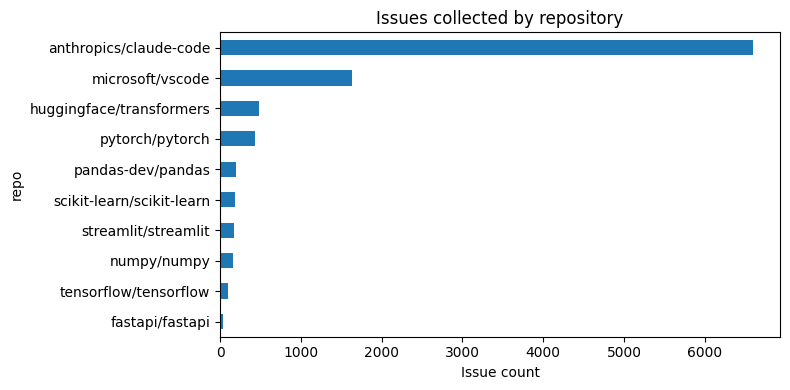

In [11]:
ax = issues["repo"].value_counts().sort_values().plot(kind="barh", figsize=(8, 4), title="Issues collected by repository")
ax.set_xlabel("Issue count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "issues_by_repository.png", dpi=150)
plt.show()

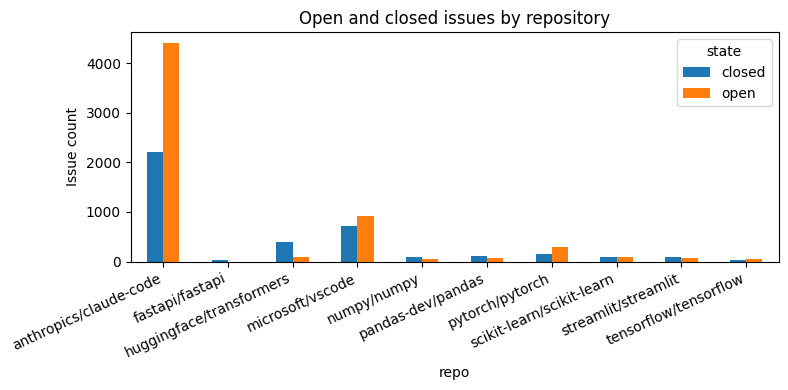

In [12]:
state_by_repo = issues.pivot_table(index="repo", columns="state", values="issue_key", aggfunc="count", fill_value=0)
ax = state_by_repo.plot(kind="bar", figsize=(8, 4), title="Open and closed issues by repository")
ax.set_ylabel("Issue count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "issue_state_by_repository.png", dpi=150)
plt.show()

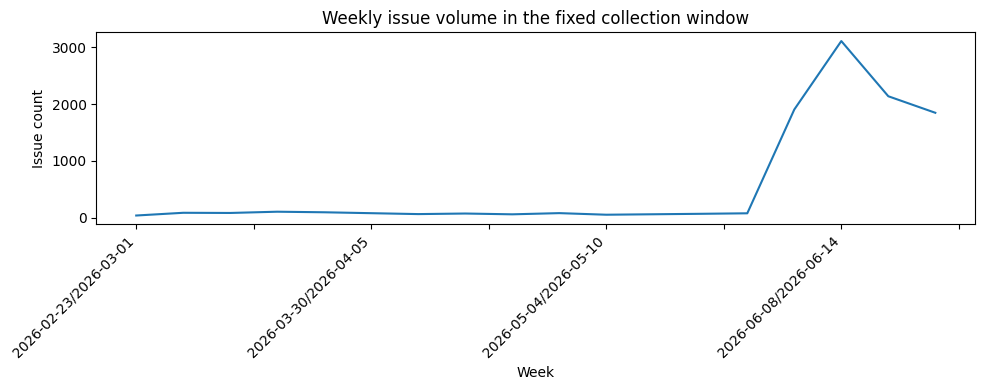

In [13]:
weekly_counts = issues.groupby("week").size()
ax = weekly_counts.plot(figsize=(10, 4), title="Weekly issue volume in the fixed collection window")
ax.set_xlabel("Week")
ax.set_ylabel("Issue count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "weekly_issue_volume.png", dpi=150)
plt.show()

## 7. Prepare Title and Bug Description Text for Similarity Search

The detector compares both parts of a bug report: the title and the bug description. I clean formatting noise while keeping issue numbers, error fragments, package names and technical words because those details can be useful for duplicate matching.


In [14]:
def clean_issue_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"```.*?```", " ", text, flags=re.DOTALL)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^A-Za-z0-9_#./:+\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def make_preview(text, max_chars=260):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text).strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + "..."


issues["clean_title"] = issues["title"].map(clean_issue_text)
issues["clean_body"] = issues["body"].map(clean_issue_text)
issues["search_text"] = (issues["clean_title"] + " " + issues["clean_body"]).str.strip()
issues["semantic_text"] = (issues["title"].fillna("") + ". " + issues["body"].fillna("")).str.slice(0, 2500)
issues["body_preview"] = issues["body"].map(make_preview)


In [15]:
duplicate_pattern = r"duplicate|dupe|same issue|same problem|already reported|already filed|same as|tracked in|related to|closed as duplicate"
bug_pattern = r"bug|error|exception|crash|fails|failure|broken|regression|traceback|incorrect|unexpected"

issues["has_bug_signal"] = issues["labels"].str.contains("bug", case=False, na=False) | issues["search_text"].str.contains(bug_pattern, regex=True, na=False)
issues["has_duplicate_signal"] = issues["labels"].str.contains("duplicate", case=False, na=False) | issues["search_text"].str.contains(duplicate_pattern, regex=True, na=False)

signal_summary = pd.DataFrame({
    "signal": ["bug-like issues", "duplicate-language issues"],
    "count": [int(issues["has_bug_signal"].sum()), int(issues["has_duplicate_signal"].sum())],
})
display(signal_summary)

,signal,count
0,bug-like issues,7985
1,duplicate-language issues,2797


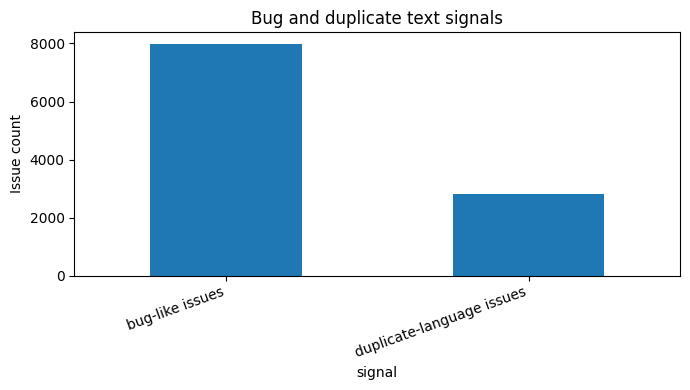

In [16]:
ax = signal_summary.set_index("signal")["count"].plot(kind="bar", figsize=(7, 4), title="Bug and duplicate text signals")
ax.set_ylabel("Issue count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bug_duplicate_text_signals.png", dpi=150)
plt.show()

### Word Cloud and Frequent Terms

This EDA looks at the cleaned title and description text from bug-like issues. I remove common GitHub and reporting words so the chart focuses more on technical terms found in the collected issue corpus.

The word cloud is only an exploratory view. It is not used as an input to the duplicate decision.


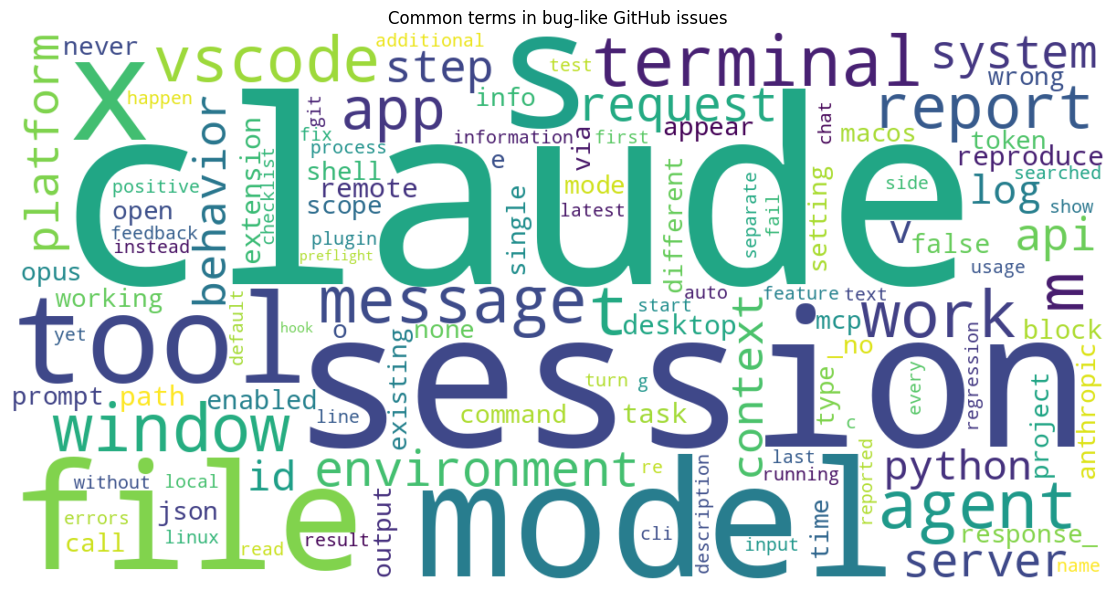

,term,frequency
0,claude,31586
1,session,15096
2,s,11367
3,model,10603
4,file,8758
5,x,8481
6,tool,7636
7,terminal,7217
8,t,6881
9,agent,6680


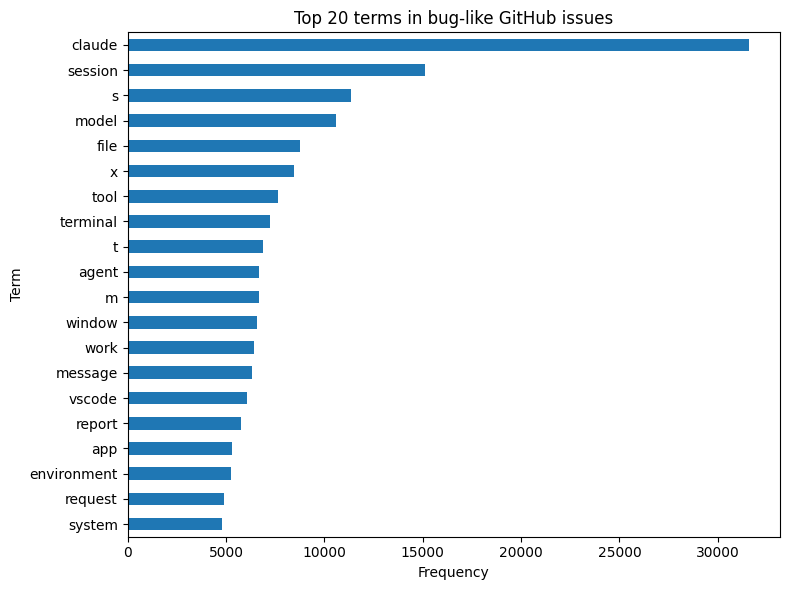

In [17]:
try:
    from wordcloud import STOPWORDS, WordCloud
except ModuleNotFoundError:
    print("Installing the wordcloud package...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "wordcloud>=1.9,<2.0",
    ])
    from wordcloud import STOPWORDS, WordCloud

bug_issue_text = " ".join(
    issues.loc[issues["has_bug_signal"], "search_text"]
    .fillna("")
    .astype(str)
    .tolist()
)

custom_stopwords = set(STOPWORDS)
custom_stopwords.update({
    "issue", "issues", "bug", "error", "problem", "problems",
    "github", "please", "using", "use", "used", "would", "could",
    "also", "one", "new", "need", "like", "make", "run", "code",
    "version", "user", "users", "expected", "actual", "currently",
})

if not bug_issue_text.strip():
    print("No bug-like issue text was available for the word cloud.")
else:
    issue_wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=120,
        stopwords=custom_stopwords,
        collocations=False,
        random_state=42,
    ).generate(bug_issue_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(issue_wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Common terms in bug-like GitHub issues")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "bug_issue_wordcloud.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    term_frequencies = issue_wordcloud.process_text(bug_issue_text)
    top_terms = (
        pd.DataFrame(
            term_frequencies.items(),
            columns=["term", "frequency"],
        )
        .sort_values("frequency", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    display(top_terms)

    ax = (
        top_terms.sort_values("frequency")
        .plot(
            kind="barh",
            x="term",
            y="frequency",
            figsize=(8, 6),
            legend=False,
            title="Top 20 terms in bug-like GitHub issues",
        )
    )
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Term")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "top_bug_issue_terms.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


## 8. Build Title, Description, and Semantic Features

The default semantic backend is scikit-learn LSA. This avoids the fragile `sentence-transformers` and `torch` dependency path while still comparing meaning from the combined title and description. A sentence-transformer model can be enabled later, but it is not required for this submission.

In [18]:
PREFER_SENTENCE_TRANSFORMER = False
AUTO_INSTALL_SENTENCE_TRANSFORMERS = False
SEMANTIC_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
SEMANTIC_BACKEND = "lsa_fallback"
SentenceTransformer = None

if PREFER_SENTENCE_TRANSFORMER:
    try:
        from sentence_transformers import SentenceTransformer as _SentenceTransformer
        SentenceTransformer = _SentenceTransformer
        SEMANTIC_BACKEND = "sentence_transformer"
        print("sentence-transformers import succeeded.")
    except Exception as exc:
        print("sentence-transformers could not be used in this environment.")
        print("Using scikit-learn LSA semantic features instead.")
        print("Import problem:", repr(exc))
else:
    print("Using scikit-learn LSA semantic backend by default.")

print("Semantic backend selected:", SEMANTIC_BACKEND)

Using scikit-learn LSA semantic backend by default.
Semantic backend selected: lsa_fallback


In [19]:
word_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, stop_words="english")
char_vectorizer = TfidfVectorizer(max_features=25000, analyzer="char_wb", ngram_range=(3, 5), min_df=2)
title_vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=1, stop_words="english")
body_vectorizer = TfidfVectorizer(max_features=35000, ngram_range=(1, 2), min_df=1, stop_words="english")

X_word = word_vectorizer.fit_transform(issues["search_text"])
X_char = char_vectorizer.fit_transform(issues["search_text"])
X_title = title_vectorizer.fit_transform(issues["clean_title"])
X_body = body_vectorizer.fit_transform(issues["clean_body"])

print("Combined title + description TF-IDF shape:", X_word.shape)
print("Character TF-IDF shape:", X_char.shape)
print("Title TF-IDF shape:", X_title.shape)
print("Bug description TF-IDF shape:", X_body.shape)


Combined title + description TF-IDF shape: (10000, 50000)
Character TF-IDF shape: (10000, 25000)
Title TF-IDF shape: (10000, 15000)
Bug description TF-IDF shape: (10000, 35000)


In [20]:
lsa_model = None
semantic_model = None


def build_lsa_semantic_features():
    n_components = min(256, max(2, min(X_word.shape) - 1))
    model = TruncatedSVD(n_components=n_components, random_state=42)
    matrix = normalize(model.fit_transform(X_word))
    return model, np.asarray(matrix, dtype=np.float32)


if SEMANTIC_BACKEND == "sentence_transformer" and SentenceTransformer is not None:
    try:
        semantic_model = SentenceTransformer(SEMANTIC_MODEL_NAME)
        X_semantic = semantic_model.encode(
            issues["semantic_text"].tolist(),
            batch_size=64,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        X_semantic = np.asarray(X_semantic, dtype=np.float32)
    except Exception as exc:
        print("Sentence-transformer model loading or encoding failed.")
        print("Falling back to safe scikit-learn LSA semantic features.")
        print("Model problem:", repr(exc))
        SEMANTIC_BACKEND = "lsa_fallback"
        lsa_model, X_semantic = build_lsa_semantic_features()
else:
    SEMANTIC_BACKEND = "lsa_fallback"
    lsa_model, X_semantic = build_lsa_semantic_features()

print("Semantic backend used:", SEMANTIC_BACKEND)
print("Semantic feature matrix:", X_semantic.shape)

Semantic backend used: lsa_fallback
Semantic feature matrix: (10000, 256)



## 9. Find Similar Bug Reports Without Hanging

This version uses a two-stage search:

1. Use semantic embeddings from the combined title and description to quickly find nearby issues.
2. Score those candidates with a hybrid score that includes semantic similarity, title similarity, bug-description similarity, combined word similarity and character similarity.
3. Apply separate review score so a strong title/body/semantic match is not hidden just because one field, such as the short title is weak.

This keeps the notebook fast while making duplicate decision depend on the full bug report instead of only the title.


In [21]:
WEIGHTS = {
    "semantic": 0.30,  # meaning of title + bug description
    "body": 0.30,      # bug-description details
    "title": 0.12,     # short summary signal, intentionally not dominant
    "word": 0.20,      # combined title + description technical terms
    "char": 0.08,      # typos and error fragments
}

# Safe defaults. Section 11 tunes likely_duplicate from evaluation queries.
THRESHOLDS = {
    "likely_duplicate": 0.58,
    "possible_duplicate": 0.40,
    "mixed_evidence": 0.40,
}


# User-facing field-match rules.
FIELD_MATCH_THRESHOLD = 0.40
WORD_MATCH_CAP = 0.40
MIN_EXACT_DESCRIPTION_CHARS = 30
MIN_PARTIAL_DESCRIPTION_TOKENS = 12
GENERIC_TITLE_WORDS = {"test", "bug", "issue", "error", "problem", "help"}


def title_is_informative(clean_title):
    tokens = re.findall(r"[a-z0-9_#./:+\-]+", clean_title.lower())
    meaningful_tokens = [token for token in tokens if token not in GENERIC_TITLE_WORDS and len(token) > 1]
    return len(meaningful_tokens) >= 2


def normalize_description_match_text(text):
    """Normalize description text for exact and copied-preview matching.

    The notebook displays shortened body previews ending in "...". This helper
    removes formatting and punctuation so a copied preview can be recognized as
    a substantial prefix or substring of the full GitHub issue description.
    """
    cleaned = clean_issue_text(text)
    return " ".join(re.findall(r"[a-z0-9_]+", cleaned.lower()))

if not np.isclose(sum(WEIGHTS.values()), 1.0):
    raise ValueError("Similarity weights must sum to 1.0")


def hybrid_score(semantic_score, body_score, title_score, word_score, char_score):
    word_score_used = min(float(word_score), WORD_MATCH_CAP)
    return float(
        WEIGHTS["semantic"] * semantic_score
        + WEIGHTS["body"] * body_score
        + WEIGHTS["title"] * title_score
        + WEIGHTS["word"] * word_score_used
        + WEIGHTS["char"] * char_score
    )


def duplicate_evidence_level(semantic_score, body_score, title_score, word_score, char_score):
    """Classify the evidence for one candidate issue.

    The duplicate decision is candidate-specific. A candidate should not become a
    high-confidence duplicate from title evidence alone or semantic evidence alone.
    Stronger decisions require the same candidate to have meaningful support from
    the description, combined technical words, or both title and description.
    """
    if title_score >= 0.35 and body_score >= 0.20:
        return "title_and_description"
    if body_score >= 0.34 and (semantic_score >= 0.50 or word_score >= 0.22):
        return "description_dominant"
    if word_score >= 0.45 and body_score >= 0.15:
        return "combined_text"
    if semantic_score >= 0.72 and body_score >= 0.20:
        return "semantic_with_description"
    if title_score >= 0.75 and (body_score >= 0.10 or word_score >= 0.28 or char_score >= 0.35):
        return "strong_title_with_support"
    if title_score >= 0.75 or body_score >= 0.30:
        return "single_field_possible"
    if semantic_score >= 0.68 and (word_score >= 0.18 or char_score >= 0.22):
        return "semantic_possible"
    return "weak_or_generic"


def build_match_reason(semantic_score, body_score, title_score, word_score, char_score, final_score, duplicate_score, evidence_level):
    reasons = []

    if title_score >= 0.35:
        reasons.append("title similarity")
    if body_score >= 0.20:
        reasons.append("bug-description similarity")
    if word_score >= 0.22:
        reasons.append("shared technical words")
    if char_score >= 0.30:
        reasons.append("similar error/text fragments")
    if semantic_score >= 0.60:
        reasons.append("semantic meaning similarity")

    if evidence_level == "weak_or_generic":
        if semantic_score >= 0.60 and body_score < 0.20 and title_score < 0.35:
            return "Semantic similarity only; not enough title/description support for a duplicate"
        return "Weak or generic similarity; review only if context requires it"

    if evidence_level == "single_field_possible":
        return "Only one field is strongly similar; possible duplicate but not high confidence"

    return "Coherent evidence: " + ", ".join(reasons) if reasons else "Coherent hybrid title + description evidence"


def coherent_duplicate_score(semantic_score, body_score, title_score, word_score, char_score):
    """Compute a duplicate-risk score with a coherence gate.

    This replaces the earlier review-score shortcut. It avoids hard-coded examples
    and avoids over-trusting a single strong signal. A likely duplicate should have
    evidence that points to the same existing issue.
    """
    final_score = hybrid_score(semantic_score, body_score, title_score, word_score, char_score)
    evidence_level = duplicate_evidence_level(semantic_score, body_score, title_score, word_score, char_score)

    if evidence_level in {"title_and_description", "description_dominant", "combined_text", "semantic_with_description"}:
        bonus = 0.04
        if title_score >= 0.50 and body_score >= 0.30:
            bonus += 0.05
        if word_score >= 0.40 or char_score >= 0.40:
            bonus += 0.03
        duplicate_score = min(1.0, final_score + bonus)
    elif evidence_level == "strong_title_with_support":
        duplicate_score = min(0.62, final_score + 0.04)
    elif evidence_level in {"single_field_possible", "semantic_possible"}:
        # A title-only or description-only match should be shown for review, but
        # it should not normally become a likely duplicate by itself.
        duplicate_score = min(0.52, max(final_score, 0.55 * title_score + 0.45 * body_score, 0.70 * body_score))
    else:
        # Cap generic semantic similarity so broad topic overlap does not create
        # false duplicates.
        duplicate_score = min(0.36, final_score)

    duplicate_score = float(np.clip(duplicate_score, 0.0, 1.0))
    reason = build_match_reason(
        semantic_score, body_score, title_score, word_score, char_score, final_score, duplicate_score, evidence_level
    )
    return final_score, duplicate_score, evidence_level, reason


def pair_score(source_idx, target_idx):
    semantic_score = float(np.dot(X_semantic[source_idx], X_semantic[target_idx]))
    body_score = float(X_body[source_idx].multiply(X_body[target_idx]).sum())
    title_score = float(X_title[source_idx].multiply(X_title[target_idx]).sum())
    word_score = float(X_word[source_idx].multiply(X_word[target_idx]).sum())
    char_score = float(X_char[source_idx].multiply(X_char[target_idx]).sum())

    final_score, duplicate_score, evidence_level, reason = coherent_duplicate_score(
        semantic_score, body_score, title_score, word_score, char_score
    )
    return semantic_score, body_score, title_score, word_score, char_score, final_score, duplicate_score, evidence_level, reason

In [22]:
def build_similarity_candidates(max_queries_per_repo=900, neighbors_per_issue=8):
    rng = np.random.default_rng(42)
    candidate_rows = []

    for repo_name in sorted(issues["repo"].unique()):
        repo_indices = issues.index[issues["repo"].eq(repo_name)].to_numpy()
        if len(repo_indices) < 2:
            continue

        sample_size = min(max_queries_per_repo, len(repo_indices))
        query_indices = rng.choice(repo_indices, size=sample_size, replace=False)
        n_neighbors = min(neighbors_per_issue + 1, len(repo_indices))

        nn = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine", algorithm="brute")
        nn.fit(X_semantic[repo_indices])
        distances, neighbor_positions = nn.kneighbors(X_semantic[query_indices])

        for q_idx, row_positions in zip(query_indices, neighbor_positions):
            added_for_query = 0
            for pos in row_positions:
                t_idx = int(repo_indices[pos])
                if t_idx == q_idx:
                    continue

                sem, body, title, word, char, final, duplicate, evidence_level, reason = pair_score(int(q_idx), t_idx)
                if added_for_query < 2 or duplicate >= 0.36:
                    q = issues.loc[int(q_idx)]
                    t = issues.loc[t_idx]
                    candidate_rows.append({
                        "repo": repo_name,
                        "source_issue_key": q["issue_key"],
                        "source_title": q["title"],
                        "source_description_preview": q["body_preview"],
                        "target_issue_key": t["issue_key"],
                        "target_title": t["title"],
                        "target_description_preview": t["body_preview"],
                        "semantic_score": round(sem, 4),
                        "body_score": round(body, 4),
                        "title_score": round(title, 4),
                        "word_score": round(word, 4),
                        "char_score": round(char, 4),
                        "final_score": round(final, 4),
                        "duplicate_score": round(duplicate, 4),
                        "evidence_level": evidence_level,
                        "match_reason": reason,
                        "source_url": q["html_url"],
                        "target_url": t["html_url"],
                    })
                    added_for_query += 1

        print(f"{repo_name}: reviewed {sample_size} query issues")

    return pd.DataFrame(candidate_rows)

In [23]:
similarity_candidates = build_similarity_candidates(max_queries_per_repo=900, neighbors_per_issue=8)

if not similarity_candidates.empty:
    similarity_candidates = similarity_candidates.sort_values("duplicate_score", ascending=False)
    similarity_candidates = similarity_candidates.drop_duplicates(subset=["source_issue_key", "target_issue_key"])
    similarity_candidates.to_csv(INTERIM_DIR / "semantic_candidate_duplicate_pairs_for_review.csv", index=False)

print("Candidate duplicate pairs for review:", len(similarity_candidates))
display(similarity_candidates.head(25))

anthropics/claude-code: reviewed 900 query issues
fastapi/fastapi: reviewed 31 query issues
huggingface/transformers: reviewed 488 query issues
microsoft/vscode: reviewed 900 query issues
numpy/numpy: reviewed 157 query issues
pandas-dev/pandas: reviewed 196 query issues
pytorch/pytorch: reviewed 437 query issues
scikit-learn/scikit-learn: reviewed 190 query issues
streamlit/streamlit: reviewed 169 query issues
tensorflow/tensorflow: reviewed 99 query issues
Candidate duplicate pairs for review: 19120


,repo,source_issue_key,source_title,source_description_preview,target_issue_key,target_title,target_description_preview,semantic_score,body_score,title_score,word_score,char_score,final_score,duplicate_score,evidence_level,match_reason,source_url,target_url
7541,microsoft/vscode,microsoft/vscode#322232,leanhhao2604@icloud.com),<!-- ⚠️⚠️ Do Not Delete This! bug_report_template ⚠️⚠️ --> <!-- Please read our Rules of Conduct: https://opensource.microsoft.com/codeofconduct/ --> <!-- 🕮 Read our guide about submitting issues: https://github.com/microsoft/vscode/wiki/Submitting-Bugs-and-Su...,microsoft/vscode#322233,leanhhao2604@icloud.com),<!-- ⚠️⚠️ Do Not Delete This! bug_report_template ⚠️⚠️ --> <!-- Please read our Rules of Conduct: https://opensource.microsoft.com/codeofconduct/ --> <!-- 🕮 Read our guide about submitting issues: https://github.com/microsoft/vscode/wiki/Submitting-Bugs-and-Su...,1.0,1.0,1.0,1.0,1.0,0.88,1.0,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",https://github.com/microsoft/vscode/issues/322232,https://github.com/microsoft/vscode/issues/322233
7540,microsoft/vscode,microsoft/vscode#322232,leanhhao2604@icloud.com),<!-- ⚠️⚠️ Do Not Delete This! bug_report_template ⚠️⚠️ --> <!-- Please read our Rules of Conduct: https://opensource.microsoft.com/codeofconduct/ --> <!-- 🕮 Read our guide about submitting issues: https://github.com/microsoft/vscode/wiki/Submitting-Bugs-and-Su...,microsoft/vscode#322231,leanhhao2604@icloud.com),<!-- ⚠️⚠️ Do Not Delete This! bug_report_template ⚠️⚠️ --> <!-- Please read our Rules of Conduct: https://opensource.microsoft.com/codeofconduct/ --> <!-- 🕮 Read our guide about submitting issues: https://github.com/microsoft/vscode/wiki/Submitting-Bugs-and-Su...,1.0,1.0,1.0,1.0,1.0,0.88,1.0,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",https://github.com/microsoft/vscode/issues/322232,https://github.com/microsoft/vscode/issues/322231
4333,anthropics/claude-code,anthropics/claude-code#70744,[cyber] False-positive block (req_011CcPQ3KbDroW7QoqCcy8Q7),"**Type:** Cybersecurity safety-filter false positive A server-side safety/policy block fired during authorized, in-scope security work in Claude Code. Filing as a false positive. Recurred **1×** across 1 session(s); first seen 2026-06-25T05:07:29.509Z. ### Req...",anthropics/claude-code#70745,[cyber] False-positive block (req_011CcPQ3KbDroW7QoqCcy8Q7),"**Type:** Cybersecurity safety-filter false positive A server-side safety/policy block fired during authorized, in-scope security work in Claude Code. Filing as a false positive. Recurred **1×** across 1 session(s); first seen 2026-06-25T05:07:29.509Z. ### Req...",1.0,1.0,1.0,1.0,1.0,0.88,1.0,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",https://github.com/anthropics/claude-code/issues/70744,https://github.com/anthropics/claude-code/issues/70745
10709,microsoft/vscode,microsoft/vscode#321377,Data is not fetching,"Type: <b>Performance Issue</b> data is fetcing will cloning for the git VS Code version: Code 1.124.2 (6928394f91b684055b873eecb8bc281365131f1c, 2026-06-12T00:12:36Z) OS version: Windows_NT x64 10.0.26200 Modes: <details> <summary>System Info</summary> |Item|V...",microsoft/vscode#321378,Data is not fetching,"Type: <b>Performance Issue</b> data is not fetcing will cloning for the git VS Code version: Code 1.124.2 (6928394f91b684055b873eecb8bc281365131f1c, 2026-06-12T00:12:36Z) OS version: Windows_NT x64 10.0.26200 Modes: <details> <summary>System Info</summary> |It...",1.0,1.0,1.0,1.0,1.0,0.88,1.0,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar erro

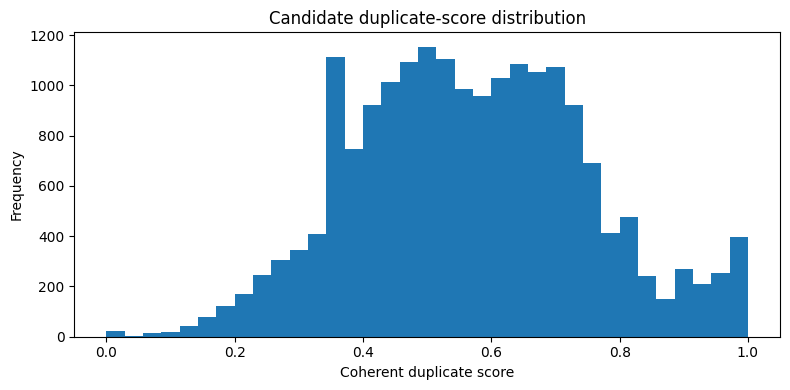

In [24]:
if not similarity_candidates.empty:
    ax = similarity_candidates["duplicate_score"].plot(
        kind="hist",
        bins=35,
        figsize=(8, 4),
        title="Candidate duplicate-score distribution",
    )
    ax.set_xlabel("Coherent duplicate score")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "candidate_duplicate_score_distribution.png", dpi=150)
    plt.show()

## 10. Manual Review File

The model produces review candidates. I do not treat them as confirmed duplicates automatically. A reviewer can label each pair as `true_duplicate`, `related`, or `not_duplicate`. That keeps the evaluation honest.

If this file already exists with human labels, the notebook preserves it instead of overwriting the labels.


In [25]:
review_path = INTERIM_DIR / "manual_duplicate_review_labels.csv"
review_columns = [
    "repo",
    "source_issue_key",
    "source_title",
    "source_description_preview",
    "target_issue_key",
    "target_title",
    "target_description_preview",
    "duplicate_score",
    "final_score",
    "semantic_score",
    "body_score",
    "title_score",
    "word_score",
    "char_score",
    "evidence_level",
    "match_reason",
    "review_label",
    "reviewer",
    "review_notes",
]

if review_path.exists():
    review_template = pd.read_csv(review_path)
    if "review_score" in review_template.columns and "duplicate_score" not in review_template.columns:
        review_template["duplicate_score"] = review_template["review_score"]
    for col in review_columns:
        if col not in review_template.columns:
            review_template[col] = ""
    review_template = review_template[review_columns]
    print("Loaded existing manual review file and preserved labels:", review_path)
else:
    if similarity_candidates.empty:
        review_template = pd.DataFrame(columns=review_columns)
    else:
        review_template = similarity_candidates.head(150).copy()
        for col in review_columns:
            if col not in review_template.columns:
                review_template[col] = ""
        review_template = review_template[review_columns]
    review_template.to_csv(review_path, index=False)
    print("Manual review template saved to:", review_path)

display(review_template.head(10))

Manual review template saved to: C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project\data\interim\manual_duplicate_review_labels.csv


,repo,source_issue_key,source_title,source_description_preview,target_issue_key,target_title,target_description_preview,duplicate_score,final_score,semantic_score,body_score,title_score,word_score,char_score,evidence_level,match_reason,review_label,reviewer,review_notes
7541,microsoft/vscode,microsoft/vscode#322232,leanhhao2604@icloud.com),<!-- ⚠️⚠️ Do Not Delete This! bug_report_template ⚠️⚠️ --> <!-- Please read our Rules of Conduct: https://opensource.microsoft.com/codeofconduct/ --> <!-- 🕮 Read our guide about submitting issues: https://github.com/microsoft/vscode/wiki/Submitting-Bugs-and-Su...,microsoft/vscode#322233,leanhhao2604@icloud.com),<!-- ⚠️⚠️ Do Not Delete This! bug_report_template ⚠️⚠️ --> <!-- Please read our Rules of Conduct: https://opensource.microsoft.com/codeofconduct/ --> <!-- 🕮 Read our guide about submitting issues: https://github.com/microsoft/vscode/wiki/Submitting-Bugs-and-Su...,1.0,0.88,1.0,1.0,1.0,1.0,1.0,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",,,
7540,microsoft/vscode,microsoft/vscode#322232,leanhhao2604@icloud.com),<!-- ⚠️⚠️ Do Not Delete This! bug_report_template ⚠️⚠️ --> <!-- Please read our Rules of Conduct: https://opensource.microsoft.com/codeofconduct/ --> <!-- 🕮 Read our guide about submitting issues: https://github.com/microsoft/vscode/wiki/Submitting-Bugs-and-Su...,microsoft/vscode#322231,leanhhao2604@icloud.com),<!-- ⚠️⚠️ Do Not Delete This! bug_report_template ⚠️⚠️ --> <!-- Please read our Rules of Conduct: https://opensource.microsoft.com/codeofconduct/ --> <!-- 🕮 Read our guide about submitting issues: https://github.com/microsoft/vscode/wiki/Submitting-Bugs-and-Su...,1.0,0.88,1.0,1.0,1.0,1.0,1.0,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",,,
4333,anthropics/claude-code,anthropics/claude-code#70744,[cyber] False-positive block (req_011CcPQ3KbDroW7QoqCcy8Q7),"**Type:** Cybersecurity safety-filter false positive A server-side safety/policy block fired during authorized, in-scope security work in Claude Code. Filing as a false positive. Recurred **1×** across 1 session(s); first seen 2026-06-25T05:07:29.509Z. ### Req...",anthropics/claude-code#70745,[cyber] False-positive block (req_011CcPQ3KbDroW7QoqCcy8Q7),"**Type:** Cybersecurity safety-filter false positive A server-side safety/policy block fired during authorized, in-scope security work in Claude Code. Filing as a false positive. Recurred **1×** across 1 session(s); first seen 2026-06-25T05:07:29.509Z. ### Req...",1.0,0.88,1.0,1.0,1.0,1.0,1.0,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",,,
10709,microsoft/vscode,microsoft/vscode#321377,Data is not fetching,"Type: <b>Performance Issue</b> data is fetcing will cloning for the git VS Code version: Code 1.124.2 (6928394f91b684055b873eecb8bc281365131f1c, 2026-06-12T00:12:36Z) OS version: Windows_NT x64 10.0.26200 Modes: <details> <summary>System Info</summary> |Item|V...",microsoft/vscode#321378,Data is not fetching,"Type: <b>Performance Issue</b> data is not fetcing will cloning for the git VS Code version: Code 1.124.2 (6928394f91b684055b873eecb8bc281365131f1c, 2026-06-12T00:12:36Z) OS version: Windows_NT x64 10.0.26200 Modes: <details> <summary>System Info</summary> |It...",1.0,0.88,1.0,1.0,1.0,1.0,1.0,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",,,
7105,huggingface/transformers,huggingface/transformers#46551,"Wav2Vec2CTCTokenizer in v5 treats the word delimiter as a special token, which leaks into get_special_tokens_mask and convert_ids_to_tokens","### System Info - transformers 5.1

## 11. Ground-Truth Pair Evaluation

Precision, recall and F1 are computed from a labeled pair file. The file is saved as `data/processed/ground_truth_duplicate_pairs.csv` with this structure:

`source_issue_key, target_issue_key, label, label_source`

Positive pairs come from explicit duplicate references in the issue text like “duplicate of #1234” or “same as #1234”. Negative pairs are fixed non-duplicate control pairs from the same repositories. The threshold is tuned only on the validation split and reported on the held-out test split.

In [26]:
LABEL_TO_INT = {"true_duplicate": 1, "duplicate": 1, "1": 1, "yes": 1, "not_duplicate": 0, "not duplicate": 0, "0": 0, "no": 0}


def pair_key(a, b):
    return tuple(sorted([str(a), str(b)]))


def extract_duplicate_issue_references(text):
    text = "" if pd.isna(text) else str(text)
    refs = set()
    duplicate_terms = re.compile(
        r"duplicate|dupe|same as|same issue|same problem|already reported|already filed|closed as duplicate|duplicates",
        flags=re.IGNORECASE,
    )
    for match in re.finditer(r"(?:#|/issues/)(\d+)", text):
        window = text[max(0, match.start() - 120): match.end() + 80]
        if duplicate_terms.search(window):
            refs.add(int(match.group(1)))
    return refs


def build_confirmed_duplicate_pairs():
    issue_key_set = set(issues["issue_key"])
    rows = []
    seen = set()

    for row in issues.itertuples(index=False):
        text = f"{row.title} {row.body} {row.labels}"
        for issue_number in extract_duplicate_issue_references(text):
            target_key = f"{row.repo}#{issue_number}"
            if target_key == row.issue_key or target_key not in issue_key_set:
                continue
            key = pair_key(row.issue_key, target_key)
            if key in seen:
                continue
            rows.append({
                "repo": row.repo,
                "source_issue_key": row.issue_key,
                "target_issue_key": target_key,
                "label": "true_duplicate",
                "label_source": "explicit_duplicate_reference",
            })
            seen.add(key)

    return pd.DataFrame(rows)


def build_non_duplicate_control_pairs(positive_pairs, target_count=None, random_state=42):
    rng = np.random.default_rng(random_state)
    positive_keys = {pair_key(r.source_issue_key, r.target_issue_key) for r in positive_pairs.itertuples(index=False)}
    rows = []

    if target_count is None:
        target_count = max(200, len(positive_pairs) * 2)

    usable = issues[(issues["search_text"].str.len() >= 60) & (~issues["has_duplicate_signal"])].copy()

    for repo_name in sorted(usable["repo"].unique()):
        repo_pool = usable[usable["repo"].eq(repo_name)]
        if len(repo_pool) < 2:
            continue

        per_repo_target = max(1, int(np.ceil(target_count / max(1, usable["repo"].nunique()))))
        attempts = 0
        repo_rows = 0
        repo_indices = repo_pool.index.to_numpy()

        while repo_rows < per_repo_target and attempts < per_repo_target * 80:
            attempts += 1
            a_idx, b_idx = rng.choice(repo_indices, size=2, replace=False)
            a = issues.loc[a_idx]
            b = issues.loc[b_idx]
            key = pair_key(a["issue_key"], b["issue_key"])
            if key in positive_keys:
                continue

            # Keep negatives from the same repository while avoiding high-overlap pairs.
            word_overlap = float(X_word[a_idx].multiply(X_word[b_idx]).sum())
            title_overlap = float(X_title[a_idx].multiply(X_title[b_idx]).sum())
            if word_overlap >= 0.16 or title_overlap >= 0.25:
                continue

            rows.append({
                "repo": repo_name,
                "source_issue_key": a["issue_key"],
                "target_issue_key": b["issue_key"],
                "label": "not_duplicate",
                "label_source": "non_duplicate_control_pair",
            })
            repo_rows += 1

    return pd.DataFrame(rows).head(target_count)


def load_or_create_ground_truth_pairs():
    required_columns = {"source_issue_key", "target_issue_key", "label"}

    if GROUND_TRUTH_PATH.exists():
        labeled_pairs = pd.read_csv(GROUND_TRUTH_PATH).fillna("")
        missing = required_columns - set(labeled_pairs.columns)
        if missing:
            raise ValueError(f"Ground-truth file is missing columns: {sorted(missing)}")
        if "label_source" not in labeled_pairs.columns:
            labeled_pairs["label_source"] = "existing_ground_truth_file"
        return labeled_pairs, "existing_ground_truth_csv"

    positive_pairs = build_confirmed_duplicate_pairs()
    if positive_pairs.empty:
        raise ValueError(
            "No explicit duplicate-reference pairs were found. Add labeled pairs to "
            f"{GROUND_TRUTH_PATH} and rerun this section."
        )

    negative_pairs = build_non_duplicate_control_pairs(positive_pairs)
    labeled_pairs = pd.concat([positive_pairs, negative_pairs], ignore_index=True)
    labeled_pairs.to_csv(GROUND_TRUTH_PATH, index=False)
    return labeled_pairs, "created_ground_truth_csv_from_confirmed_references"


def prepare_labeled_pairs(labeled_pairs):
    pairs = labeled_pairs.copy()
    pairs["label_clean"] = pairs["label"].astype(str).str.strip().str.lower()
    pairs = pairs[pairs["label_clean"].isin(LABEL_TO_INT)].copy()
    pairs["y_true"] = pairs["label_clean"].map(LABEL_TO_INT).astype(int)

    issue_key_to_index = dict(zip(issues["issue_key"], issues.index))
    pairs["source_idx"] = pairs["source_issue_key"].map(issue_key_to_index)
    pairs["target_idx"] = pairs["target_issue_key"].map(issue_key_to_index)
    pairs = pairs.dropna(subset=["source_idx", "target_idx"]).copy()
    pairs["source_idx"] = pairs["source_idx"].astype(int)
    pairs["target_idx"] = pairs["target_idx"].astype(int)
    pairs = pairs[pairs["source_idx"] != pairs["target_idx"]].copy()

    if pairs["y_true"].nunique() < 2:
        raise ValueError("Ground-truth file must contain both true_duplicate and not_duplicate labels.")
    if len(pairs) < 30:
        raise ValueError("Ground-truth file has fewer than 30 usable pairs; add more labeled pairs before final evaluation.")

    return pairs.reset_index(drop=True)


def score_labeled_pairs(pairs):
    rows = []
    for row in pairs.itertuples(index=False):
        semantic_score, body_score, title_score, word_score, char_score, final_score, duplicate_score, evidence_level, reason = pair_score(
            int(row.source_idx), int(row.target_idx)
        )
        rows.append({
            "repo": getattr(row, "repo", ""),
            "source_issue_key": row.source_issue_key,
            "target_issue_key": row.target_issue_key,
            "label": row.label_clean,
            "y_true": int(row.y_true),
            "label_source": getattr(row, "label_source", ""),
            "duplicate_score": duplicate_score,
            "final_score": final_score,
            "semantic_score": semantic_score,
            "body_score": body_score,
            "title_score": title_score,
            "word_score": word_score,
            "char_score": char_score,
            "evidence_level": evidence_level,
            "match_reason": reason,
        })
    return pd.DataFrame(rows)


def evaluate_threshold_grid(scored_pairs, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.30, 0.86, 0.01), 2)

    y_true = scored_pairs["y_true"].astype(int).to_numpy()
    scores = scored_pairs["duplicate_score"].astype(float).to_numpy()
    rows = []

    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "threshold": float(threshold),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })

    return pd.DataFrame(rows)


def choose_thresholds_from_validation(threshold_results):
    # Pre-save triage should avoid excessive false duplicate warnings, so precision is preferred
    # when F1 scores are close.
    candidates = threshold_results[(threshold_results["precision"] >= 0.85) & (threshold_results["recall"] >= 0.50)].copy()
    if candidates.empty:
        candidates = threshold_results.copy()

    best = candidates.sort_values(["f1", "precision", "recall"], ascending=False).iloc[0]
    likely_threshold = float(round(best["threshold"], 2))
    possible_threshold = float(round(max(0.30, likely_threshold - 0.18), 2))
    return {
        "likely_duplicate": likely_threshold,
        "possible_duplicate": possible_threshold,
        "mixed_evidence": 0.40,
    }


def summarize_at_threshold(scored_pairs, threshold):
    y_true = scored_pairs["y_true"].astype(int).to_numpy()
    y_pred = (scored_pairs["duplicate_score"].astype(float).to_numpy() >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


raw_labeled_pairs, ground_truth_source = load_or_create_ground_truth_pairs()
labeled_pairs = prepare_labeled_pairs(raw_labeled_pairs)

validation_pairs, test_pairs = train_test_split(
    labeled_pairs,
    test_size=0.35,
    random_state=42,
    stratify=labeled_pairs["y_true"],
)

validation_scored = score_labeled_pairs(validation_pairs)
test_scored = score_labeled_pairs(test_pairs)

threshold_results = evaluate_threshold_grid(validation_scored)
THRESHOLDS = choose_thresholds_from_validation(threshold_results)

validation_metrics = summarize_at_threshold(validation_scored, THRESHOLDS["likely_duplicate"])
test_metrics = summarize_at_threshold(test_scored, THRESHOLDS["likely_duplicate"])
selected_threshold_row = threshold_results.loc[
    threshold_results["threshold"].sub(THRESHOLDS["likely_duplicate"]).abs().idxmin()
].copy()

confusion_df = pd.DataFrame(
    [[test_metrics["true_negatives"], test_metrics["false_positives"]], [test_metrics["false_negatives"], test_metrics["true_positives"]]],
    index=["actual_not_duplicate", "actual_duplicate"],
    columns=["predicted_not_duplicate", "predicted_duplicate"],
)

EVALUATION_SUMMARY = {
    "evaluation_source": ground_truth_source,
    "ground_truth_file": str(GROUND_TRUTH_PATH),
    "labeled_pair_count": int(len(labeled_pairs)),
    "validation_pair_count": int(len(validation_scored)),
    "test_pair_count": int(len(test_scored)),
    "positive_pair_count": int(labeled_pairs["y_true"].sum()),
    "negative_pair_count": int((labeled_pairs["y_true"] == 0).sum()),
    "score_used_for_thresholds": "duplicate_score",
    "threshold_tuned_on": "validation_split",
    "metrics_reported_on": "held_out_test_split",
    "likely_duplicate_threshold": float(THRESHOLDS["likely_duplicate"]),
    "possible_duplicate_threshold": float(THRESHOLDS["possible_duplicate"]),
    "mixed_evidence_threshold": float(THRESHOLDS["mixed_evidence"]),
    "validation_precision": validation_metrics["precision"],
    "validation_recall": validation_metrics["recall"],
    "validation_f1": validation_metrics["f1"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "f1": test_metrics["f1"],
    "true_positives": test_metrics["true_positives"],
    "false_positives": test_metrics["false_positives"],
    "false_negatives": test_metrics["false_negatives"],
    "true_negatives": test_metrics["true_negatives"],
}

metrics_path = TABLES_DIR / "validation_threshold_precision_recall_f1.csv"
validation_pairs_path = TABLES_DIR / "validation_pairs_scored.csv"
test_pairs_path = TABLES_DIR / "heldout_test_pairs_scored.csv"
summary_path = OUTPUTS_DIR / "evaluation_summary.json"

threshold_results.to_csv(metrics_path, index=False)
validation_scored.to_csv(validation_pairs_path, index=False)
test_scored.to_csv(test_pairs_path, index=False)
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(EVALUATION_SUMMARY, f, indent=2)

print("Ground-truth source:", ground_truth_source)
print("Ground-truth pairs:", len(labeled_pairs))
print("Tuned thresholds:", THRESHOLDS)
print("Saved threshold metrics to:", metrics_path)
print("Saved held-out test scores to:", test_pairs_path)
display(pd.DataFrame([EVALUATION_SUMMARY]))
display(confusion_df)
display(test_scored.sort_values("duplicate_score", ascending=False).head(12))

Ground-truth source: created_ground_truth_csv_from_confirmed_references
Ground-truth pairs: 271
Tuned thresholds: {'likely_duplicate': 0.3, 'possible_duplicate': 0.3, 'mixed_evidence': 0.4}
Saved threshold metrics to: C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project\outputs\tables\validation_threshold_precision_recall_f1.csv
Saved held-out test scores to: C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project\outputs\tables\heldout_test_pairs_scored.csv


,evaluation_source,ground_truth_file,labeled_pair_count,validation_pair_count,test_pair_count,positive_pair_count,negative_pair_count,score_used_for_thresholds,threshold_tuned_on,metrics_reported_on,...,validation_precision,validation_recall,validation_f1,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives
0,created_ground_truth_csv_from_confirmed_references,C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project\data\processed\ground_truth_duplicate_pairs.csv,271,176,95,71,200,duplicate_score,validation_split,held_out_test_split,...,0.96875,0.673913,0.794872,1.0,0.68,0.809524,17,0,8,70


,predicted_not_duplicate,predicted_duplicate
actual_not_duplicate,70,0
actual_duplicate,8,17


,repo,source_issue_key,target_issue_key,label,y_true,label_source,duplicate_score,final_score,semantic_score,body_score,title_score,word_score,char_score,evidence_level,match_reason
31,anthropics/claude-code,anthropics/claude-code#68351,anthropics/claude-code#68346,true_duplicate,1,explicit_duplicate_reference,0.906510,0.786510,0.981270,0.925501,0.505206,0.917691,0.923171,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
84,anthropics/claude-code,anthropics/claude-code#70440,anthropics/claude-code#69405,true_duplicate,1,explicit_duplicate_reference,0.700040,0.580040,0.873501,0.351870,0.684115,0.393422,0.645633,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
14,anthropics/claude-code,anthropics/claude-code#70102,anthropics/claude-code#69631,true_duplicate,1,explicit_duplicate_reference,0.680065,0.610065,0.833058,0.663161,0.157239,0.648326,0.779137,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
47,anthropics/claude-code,anthropics/claude-code#68896,anthropics/claude-code#65883,true_duplicate,1,explicit_duplicate_reference,0.613664,0.543664,0.844092,0.458429,0.251018,0.452499,0.534824,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
69,anthropics/claude-code,anthropics/claude-code#65598,anthropics/claude-code#64706,true_duplicate,1,explicit_duplicate_reference,0.611745,0.541745,0.846739,0.436809,0.182544,0.442457,0.684693,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
4,anthropics/claude-code,anthropics/claude-code#67486,anthropics/claude-code#66421,true_duplicate,1,explicit_duplicate_reference,0.598994,0.528994,0.795935,0.463058,0.204261,0.443344,0.584810,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
38,anthropics/claude-code,anthropics/claude-code#70450,anthropics/claude-code#67240,true_duplicate,1,explicit_duplicate_reference,0.572759,0.502759,0.840564,0.341716,0.209105,0.322834,0.730192,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
82,anthropics/claude-code,anthropics/claude-code#71225,anthropics/claude-code#68514,true_duplicate,1,explicit_duplicate_reference,0.545887,0.475887,0.699801,0.364796,0.301613,0.372060,0.573776,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
44,anthropics/claude-code,anthropics/claude-code#65167,anthropics/claude-code#64956,true_duplicate,1,explicit_duplicate_reference,0.543883,0.473883,0.710441,0.396128,0.091253,0.393810,0.652497,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"
73,anthropics/claude-code,anthropics/claude-code#66402,anthropics/claude-code#65598,true_duplicate,1,explicit_duplicate_reference,0.543463,0.473463,0.829104,0.320808,0.133245,0.328770,0.584332,semantic_with_description,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity"


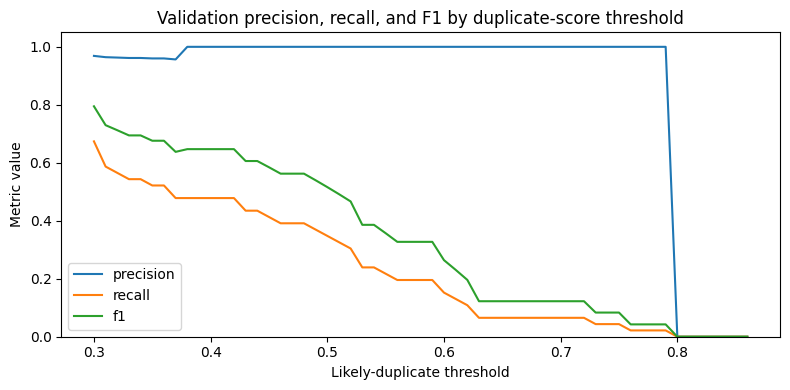

In [27]:
ax = threshold_results.plot(
    x="threshold",
    y=["precision", "recall", "f1"],
    figsize=(8, 4),
    title="Validation precision, recall, and F1 by duplicate-score threshold",
)
ax.set_xlabel("Likely-duplicate threshold")
ax.set_ylabel("Metric value")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 12. Test the Detector Inside the Notebook

The exact same issue is **not excluded** because a pre-save duplicate detector should find an already-existing issue if a user tries to submit the same report again.

The detector sorts by **duplicate_score**. The table also shows the plain weighted `final_score`, but the user-facing decision uses `duplicate_score` with coherent title-description evidence.


In [28]:
def encode_query_semantic(title, body):
    query_text = f"{title}. {body}"[:2500]
    if SEMANTIC_BACKEND == "sentence_transformer":
        return np.asarray(
            semantic_model.encode([query_text], normalize_embeddings=True),
            dtype=np.float32,
        )

    query_clean = clean_issue_text(f"{title} {body}")
    return np.asarray(normalize(lsa_model.transform(word_vectorizer.transform([query_clean]))), dtype=np.float32)


def vectorize_query_tfidf(title, body):
    clean_title = clean_issue_text(title)
    clean_body = clean_issue_text(body)
    search_text = f"{clean_title} {clean_body}".strip()
    return {
        "word": word_vectorizer.transform([search_text]),
        "char": char_vectorizer.transform([search_text]),
        "title": title_vectorizer.transform([clean_title]),
        "body": body_vectorizer.transform([clean_body]),
        "clean_title": clean_title,
        "clean_body": clean_body,
        "search_text": search_text,
    }

In [29]:
def detect_mixed_evidence(repo_indices, title_scores, body_scores, duplicate_scores):
    if len(repo_indices) == 0:
        return False, {}

    title_top_pos = int(np.argmax(title_scores))
    body_top_pos = int(np.argmax(body_scores))

    title_top_key = issues.iloc[int(repo_indices[title_top_pos])]["issue_key"]
    body_top_key = issues.iloc[int(repo_indices[body_top_pos])]["issue_key"]

    mixed = (
        title_top_key != body_top_key
        and float(title_scores[title_top_pos]) >= 0.55
        and float(body_scores[body_top_pos]) >= 0.25
        and float(np.max(duplicate_scores)) < THRESHOLDS["likely_duplicate"]
    )

    details = {
        "title_top_issue_key": title_top_key,
        "title_top_score": float(title_scores[title_top_pos]),
        "body_top_issue_key": body_top_key,
        "body_top_score": float(body_scores[body_top_pos]),
    }
    return bool(mixed), details


def score_new_issue_against_repo(repo_name, title, body, top_k=10, exclude_issue_key=None):
    repo_indices = issues.index[issues["repo"].eq(repo_name)].to_numpy()
    if len(repo_indices) == 0:
        raise ValueError(f"No issues found for {repo_name}")

    if not clean_issue_text(f"{title} {body}"):
        return pd.DataFrame()

    q_sem = encode_query_semantic(title, body)
    q_tfidf = vectorize_query_tfidf(title, body)
    clean_title = q_tfidf["clean_title"]
    clean_body = q_tfidf["clean_body"]
    informative_title = title_is_informative(clean_title)

    semantic_scores = cosine_similarity(q_sem, X_semantic[repo_indices]).ravel()
    body_scores = cosine_similarity(q_tfidf["body"], X_body[repo_indices]).ravel()
    title_scores = cosine_similarity(q_tfidf["title"], X_title[repo_indices]).ravel()
    word_scores = cosine_similarity(q_tfidf["word"], X_word[repo_indices]).ravel()
    char_scores = cosine_similarity(q_tfidf["char"], X_char[repo_indices]).ravel()

    # Description text is checked separately from TF-IDF.
    # This handles both a complete copied description and a substantial copied
    # notebook preview that ends in "...".
    query_match_body = normalize_description_match_text(body)
    repo_match_bodies = (
        issues.loc[repo_indices, "body"]
        .fillna("")
        .astype(str)
        .map(normalize_description_match_text)
        .to_numpy()
    )

    exact_description_matches = np.zeros(len(repo_indices), dtype=bool)
    partial_description_matches = np.zeros(len(repo_indices), dtype=bool)

    query_token_count = len(query_match_body.split())
    if len(query_match_body) >= MIN_EXACT_DESCRIPTION_CHARS:
        exact_description_matches = repo_match_bodies == query_match_body

    if query_token_count >= MIN_PARTIAL_DESCRIPTION_TOKENS:
        partial_description_matches = np.asarray([
            bool(candidate_body)
            and not bool(exact_description_matches[pos])
            and min(query_token_count, len(candidate_body.split())) >= MIN_PARTIAL_DESCRIPTION_TOKENS
            and (
                query_match_body in candidate_body
                or candidate_body in query_match_body
            )
            for pos, candidate_body in enumerate(repo_match_bodies)
        ], dtype=bool)

    description_text_matches = exact_description_matches | partial_description_matches
    body_scores = np.where(description_text_matches, 1.0, body_scores)

    final_scores = []
    duplicate_scores = []
    evidence_levels = []
    reasons = []

    for sem, body_score, title_score, word_score, char_score in zip(
        semantic_scores, body_scores, title_scores, word_scores, char_scores
    ):
        final, duplicate, evidence_level, reason = coherent_duplicate_score(
            float(sem), float(body_score), float(title_score), float(word_score), float(char_score)
        )
        final_scores.append(final)
        duplicate_scores.append(duplicate)
        evidence_levels.append(evidence_level)
        reasons.append(reason)

    final_scores = np.asarray(final_scores)
    duplicate_scores = np.asarray(duplicate_scores)
    mixed_evidence, mixed_details = detect_mixed_evidence(repo_indices, title_scores, body_scores, duplicate_scores)

    ranked_positions = sorted(
        range(len(repo_indices)),
        key=lambda pos: (
            bool(description_text_matches[pos]),
            bool(exact_description_matches[pos]),
            float(duplicate_scores[pos]),
            float(body_scores[pos]),
            float(title_scores[pos]),
        ),
        reverse=True,
    )

    rows = []
    for pos in ranked_positions:
        description_pass = float(body_scores[pos]) >= FIELD_MATCH_THRESHOLD
        title_pass = informative_title and float(title_scores[pos]) >= FIELD_MATCH_THRESHOLD

        # A generic one-word title such as "test" cannot create a title-only warning.
        if not description_text_matches[pos] and not description_pass and not title_pass:
            continue

        issue_idx = int(repo_indices[pos])
        row = issues.loc[issue_idx]
        if exclude_issue_key and row["issue_key"] == exclude_issue_key:
            continue

        rows.append({
            "rank": len(rows) + 1,
            "issue_key": row["issue_key"],
            "matched_title": row["title"],
            "matched_description_preview": row["body_preview"],
            "duplicate_score": round(float(duplicate_scores[pos]), 4),
            "final_score": round(float(final_scores[pos]), 4),
            "semantic_score": round(float(semantic_scores[pos]), 4),
            "body_score": round(float(body_scores[pos]), 4),
            "title_score": round(float(title_scores[pos]), 4),
            "title_match_percent": round(float(title_scores[pos]) * 100, 1),
            "description_match_percent": round(float(body_scores[pos]) * 100, 1),
            "exact_description_match": bool(exact_description_matches[pos]),
            "partial_description_match": bool(partial_description_matches[pos]),
            "description_text_match": bool(description_text_matches[pos]),
            "description_match_type": (
                "exact_full_description"
                if exact_description_matches[pos]
                else "copied_preview_or_substring"
                if partial_description_matches[pos]
                else "similarity_score"
            ),
            "word_score": round(float(word_scores[pos]), 4),
            "word_score_used": round(min(float(word_scores[pos]), WORD_MATCH_CAP), 4),
            "char_score": round(float(char_scores[pos]), 4),
            "evidence_level": evidence_levels[pos],
            "match_reason": reasons[pos],
            "mixed_evidence_flag": mixed_evidence,
            "state": row["state"],
            "url": row["html_url"],
        })
        if len(rows) >= top_k:
            break

    result = pd.DataFrame(rows)
    result.attrs["mixed_evidence"] = mixed_evidence
    result.attrs["mixed_evidence_details"] = mixed_details
    result.attrs["title_is_informative"] = informative_title
    result.attrs["field_match_threshold"] = FIELD_MATCH_THRESHOLD
    result.attrs["word_match_cap"] = WORD_MATCH_CAP
    return result


In [30]:
def decision_from_results(results):
    if results.empty:
        return "NO MATCHING DUPLICATE FOUND IN THE COLLECTED CORPUS"

    exact_matches = results[results["exact_description_match"]]
    if not exact_matches.empty:
        best = exact_matches.iloc[0]
        return (
            f"DUPLICATE OF THIS BUG - {best['issue_key']} | "
            f"{best['matched_title']}"
        )

    direct_matches = results[
        (results["title_score"] >= FIELD_MATCH_THRESHOLD)
        & (results["body_score"] >= FIELD_MATCH_THRESHOLD)
    ]
    if not direct_matches.empty:
        best = direct_matches.iloc[0]
        return (
            f"DUPLICATE OF THIS BUG - {best['issue_key']} | "
            f"{best['matched_title']}"
        )

    return "POSSIBLE DUPLICATE - review the matching issue IDs, titles, and descriptions"


# Demo: use one real issue as a new bug report. The same issue is kept in the corpus
# because a pre-save duplicate detector should find an already-existing bug if a user
# submits the same report again.
demo_pool = issues[issues["search_text"].str.len().ge(40)].copy()
if demo_pool.empty:
    demo_pool = issues.copy()

demo_row = demo_pool.iloc[0]
demo_results = score_new_issue_against_repo(
    repo_name=demo_row["repo"],
    title=demo_row["title"],
    body=demo_row["body"],
    top_k=10,
    exclude_issue_key=None,
)

print("Test issue used as a new bug report:")
print(demo_row["issue_key"], "-", demo_row["title"])
print("Decision:", decision_from_results(demo_results))
display(demo_results)

Test issue used as a new bug report:
anthropics/claude-code#71318 - [BUG] Ctrl + R randomly show 2 different UIs
Decision: DUPLICATE OF THIS BUG - anthropics/claude-code#71318 | [BUG] Ctrl + R randomly show 2 different UIs


,rank,issue_key,matched_title,matched_description_preview,duplicate_score,final_score,semantic_score,body_score,title_score,title_match_percent,...,description_text_match,description_match_type,word_score,word_score_used,char_score,evidence_level,match_reason,mixed_evidence_flag,state,url
0,1,anthropics/claude-code#71318,[BUG] Ctrl + R randomly show 2 different UIs,### Preflight Checklist - [x] I have searched [existing issues](https://github.com/anthropics/claude-code/issues?q=is%3Aissue%20state%3Aopen%20label%3Abug) and this hasn't been reported yet - [x] This is a single bug report (please file separate reports for di...,1.0000,0.8800,1.0000,1.0000,1.0000,100.0,...,True,exact_full_description,1.0000,0.400,1.0000,title_and_description,"Coherent evidence: title similarity, bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",False,open,https://github.com/anthropics/claude-code/issues/71318
1,2,anthropics/claude-code#64680,[BUG],### Preflight Checklist - [x] I have searched [existing issues](https://github.com/anthropics/claude-code/issues?q=is%3Aissue%20state%3Aopen%20label%3Abug) and this hasn't been reported yet - [x] This is a single bug report (please file separate reports for di...,0.6242,0.5542,0.7790,0.5644,0.1272,12.7,...,False,similarity_score,0.4533,0.400,0.6993,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",False,closed,https://github.com/anthropics/claude-code/issues/64680
2,3,anthropics/claude-code#68507,[BUG],### Preflight Checklist - [x] I have searched [existing issues](https://github.com/anthropics/claude-code/issues?q=is%3Aissue%20state%3Aopen%20label%3Abug) and this hasn't been reported yet - [x] This is a single bug report (please file separate reports for di...,0.6180,0.5480,0.7810,0.5433,0.1272,12.7,...,False,similarity_score,0.4363,0.400,0.6927,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",False,closed,https://github.com/anthropics/claude-code/issues/68507
3,4,anthropics/claude-code#69949,[BUG],### Preflight Checklist - [x] I have searched [existing issues](https://github.com/anthropics/claude-code/issues?q=is%3Aissue%20state%3Aopen%20label%3Abug) and this hasn't been reported yet - [x] This is a single bug report (please file separate reports for di...,0.6165,0.5465,0.7821,0.5381,0.1272,12.7,...,False,similarity_score,0.4326,0.400,0.6899,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",False,open,https://github.com/anthropics/claude-code/issues/69949
4,5,anthropics/claude-code#67731,[BUG],### Preflight Checklist - [x] I have searched [existing issues](https://github.com/anthropics/claude-code/issues?q=is%3Aissue%20state%3Aopen%20label%3Abug) and this hasn't been reported yet - [x] This is a single bug report (please file separate reports for di...,0.6165,0.5465,0.7821,0.5374,0.1272,12.7,...,False,similarity_score,0.4322,0.400,0.6920,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",False,closed,https://github.com/anthropics/claude-code/issues/67731
5,6,anthropics/claude-code#66569,[BUG],### Preflight Checklist - [x] I have searched [existing issues](https://github.com/anthropics/claude-code/issues?q=is%3Aissue%20state%3Aopen%20label%3Abug) and this hasn't been reported yet - [x] This is a single bug report (please file separate reports for di...,0.6064,0.5364,0.7786,0.5118,0.1272,12.7,...,False,similarity_score,0.4017,0.400,0.6754,description_dominant,"Coherent evidence: bug-description similarity, shared technical words, similar error/text fragments, semantic meaning similarity",False,open,https://github.com/anthropics/claude-code/issue

## 13. Save Artifacts for the App

The Streamlit app uses the same vectorizers, semantic features, thresholds and cleaned issue corpus created in the notebook. Saving these artifacts keeps the UI consistent with the notebook results. The saved model includes a separate bug-description vectorizer so the app does not make decisions from title similarity alone.


In [31]:
ARTIFACT_PATH = MODELS_DIR / "duplicate_bug_detector_artifacts.joblib"
APP_VERSION = "v11_ten_repositories_wordcloud_eda"

artifacts = {
    "artifact_version": APP_VERSION,
    "app_version": APP_VERSION,
    "corpus": issues,
    "word_vectorizer": word_vectorizer,
    "char_vectorizer": char_vectorizer,
    "title_vectorizer": title_vectorizer,
    "body_vectorizer": body_vectorizer,
    "X_word": X_word,
    "X_char": X_char,
    "X_title": X_title,
    "X_body": X_body,
    "X_semantic": X_semantic,
    "weights": WEIGHTS,
    "thresholds": THRESHOLDS,
    "field_match_threshold": FIELD_MATCH_THRESHOLD,
    "word_match_cap": WORD_MATCH_CAP,
    "min_exact_description_chars": MIN_EXACT_DESCRIPTION_CHARS,
    "min_partial_description_tokens": MIN_PARTIAL_DESCRIPTION_TOKENS,
    "generic_title_words": sorted(GENERIC_TITLE_WORDS),
    "evaluation_summary": EVALUATION_SUMMARY,
    "semantic_backend": SEMANTIC_BACKEND,
    "semantic_model_name": SEMANTIC_MODEL_NAME,
    "collection_window": {"start_date": str(START_DATE.date()), "end_date": str(END_DATE.date()), "days_back": DAYS_BACK},
    "repositories": list(REPO_CONFIG.keys()),
    "ground_truth_file": str(GROUND_TRUTH_PATH),
    "requirements_file": str(REQUIREMENTS_PATH),
    "requires_github_token": bool(REQUIRE_GITHUB_TOKEN),
    "synthetic_data_used": False,
    "data_source_mode": DATA_SOURCE_MODE,
    "score_used_for_decision": "duplicate_score",
    "decision_logic": "original_collection_with_exact_and_copied_preview_description_matching",
}

if SEMANTIC_BACKEND != "sentence_transformer":
    artifacts["lsa_model"] = lsa_model

joblib.dump(artifacts, ARTIFACT_PATH)
print("Saved artifacts to:", ARTIFACT_PATH)
print("Artifact/app version:", APP_VERSION)

Saved artifacts to: C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project\models\duplicate_bug_detector_artifacts.joblib
Artifact/app version: v11_ten_repositories_wordcloud_eda


In [32]:
metadata = {
    "project": "duplicate_bug_detector",
    "artifact_version": APP_VERSION,
    "repositories": list(REPO_CONFIG.keys()),
    "start_date": str(START_DATE.date()),
    "end_date": str(END_DATE.date()),
    "days_back": DAYS_BACK,
    "row_count": int(len(issues)),
    "minimum_target_rows": int(MIN_TARGET_ROWS),
    "dataset_target_met": bool(DATASET_TARGET_MET),
    "candidate_duplicate_pairs": int(len(similarity_candidates)),
    "semantic_backend": SEMANTIC_BACKEND,
    "semantic_model_name": SEMANTIC_MODEL_NAME,
    "weights": WEIGHTS,
    "thresholds": THRESHOLDS,
    "score_used_for_decision": "duplicate_score",
    "decision_logic": "live_github_title_description_evidence_tuned_on_ground_truth_validation_split",
    "evaluation_summary": EVALUATION_SUMMARY,
    "use_live_github_data": USE_LIVE_GITHUB_DATA,
    "use_cache_if_github_fails": USE_CACHE_IF_GITHUB_FAILS,
    "data_source_mode": DATA_SOURCE_MODE,
    "token_used": bool(GITHUB_TOKEN),
    "api_error_count": len(api_errors),
    "ground_truth_file": str(GROUND_TRUTH_PATH),
    "requirements_file": str(REQUIREMENTS_PATH),
    "requires_github_token": bool(REQUIRE_GITHUB_TOKEN),
    "real_data_only": True,
    "synthetic_data_used": False,
}

with open(COLLECTION_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata to:", COLLECTION_METADATA_PATH)

Saved metadata to: C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project\outputs\collection_metadata.json


## 14. Build the Streamlit UI

The app is the user-facing part of the project. User enters a bug title and bug description before saving. The app searches collected GitHub issue corpus using both fields and returns the closest duplicate-risk candidates.

The UI uses the same saved vectorizers, scores, thresholds and corpus produced by this notebook run. If an old browser tab shows an earlier title or version, close it and use the new URL printed by the launch cell.

In [33]:
APP_PATH = APP_DIR / "streamlit_app.py"

APP_CODE = r"""import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

ROOT = Path(__file__).resolve().parents[1]
ARTIFACT_PATH = ROOT / "models" / "duplicate_bug_detector_artifacts.joblib"
EXPECTED_APP_VERSION = "v11_ten_repositories_wordcloud_eda"

st.set_page_config(page_title="Github Duplicate Bug detector", layout="wide")
st.title("Github Duplicate Bug detector")
st.write(
    "Enter a bug title and description before saving. The app compares both fields "
    "against the live-collected GitHub issue corpus and shows the closest duplicate-risk candidates."
)

if not ARTIFACT_PATH.exists():
    st.error("Model artifacts were not found. Run the notebook through Section 13 first.")
    st.stop()

artifacts = joblib.load(ARTIFACT_PATH)
required_keys = [
    "app_version",
    "body_vectorizer",
    "X_body",
    "thresholds",
    "evaluation_summary",
    "score_used_for_decision",
    "decision_logic",
]
missing_keys = [key for key in required_keys if key not in artifacts]
if missing_keys:
    st.error("The saved artifacts are from an older version. Run the notebook from Section 8 through Section 14, then restart the app.")
    st.write("Missing artifact keys:", missing_keys)
    st.stop()

app_version = artifacts.get("app_version", "unknown")
if app_version != EXPECTED_APP_VERSION:
    st.warning(f"Artifact version is {app_version}, expected {EXPECTED_APP_VERSION}. Re-run Sections 8-14 if results look stale.")

corpus = artifacts["corpus"].copy()
word_vectorizer = artifacts["word_vectorizer"]
char_vectorizer = artifacts["char_vectorizer"]
title_vectorizer = artifacts["title_vectorizer"]
body_vectorizer = artifacts["body_vectorizer"]
X_word = artifacts["X_word"]
X_char = artifacts["X_char"]
X_title = artifacts["X_title"]
X_body = artifacts["X_body"]
X_semantic = artifacts["X_semantic"]
weights = artifacts["weights"]
thresholds = artifacts["thresholds"]
evaluation_summary = artifacts["evaluation_summary"]
semantic_backend = artifacts["semantic_backend"]
semantic_model_name = artifacts["semantic_model_name"]
FIELD_MATCH_THRESHOLD = float(artifacts.get("field_match_threshold", 0.40))
WORD_MATCH_CAP = float(artifacts.get("word_match_cap", 0.40))
MIN_EXACT_DESCRIPTION_CHARS = int(artifacts.get("min_exact_description_chars", 30))
MIN_PARTIAL_DESCRIPTION_TOKENS = int(artifacts.get("min_partial_description_tokens", 12))
GENERIC_TITLE_WORDS = set(artifacts.get("generic_title_words", ["test", "bug", "issue", "error", "problem", "help"]))

lsa_model = artifacts.get("lsa_model")
semantic_model = None
if semantic_backend == "sentence_transformer":
    try:
        from sentence_transformers import SentenceTransformer
        semantic_model = SentenceTransformer(semantic_model_name)
    except Exception as exc:
        st.error(
            "The artifacts were built with sentence-transformers, but this Streamlit environment cannot load that package. "
            "Re-run the notebook in this same environment so it can create the safe LSA fallback artifacts, then restart Streamlit."
        )
        st.caption(f"Loading problem: {exc!r}")
        st.stop()


def clean_issue_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"```.*?```", " ", text, flags=re.DOTALL)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^A-Za-z0-9_#./:+\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def title_is_informative(clean_title):
    tokens = re.findall(r"[a-z0-9_#./:+\\-]+", clean_title.lower())
    meaningful_tokens = [token for token in tokens if token not in GENERIC_TITLE_WORDS and len(token) > 1]
    return len(meaningful_tokens) >= 2


def normalize_description_match_text(text):
    cleaned = clean_issue_text(text)
    return " ".join(re.findall(r"[a-z0-9_]+", cleaned.lower()))


def make_preview(text, max_chars=260):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text).strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + "..."


def hybrid_score(semantic_score, body_score, title_score, word_score, char_score):
    word_score_used = min(float(word_score), WORD_MATCH_CAP)
    return float(
        weights["semantic"] * semantic_score
        + weights["body"] * body_score
        + weights["title"] * title_score
        + weights["word"] * word_score_used
        + weights["char"] * char_score
    )


def duplicate_evidence_level(semantic_score, body_score, title_score, word_score, char_score):
    if title_score >= 0.35 and body_score >= 0.20:
        return "title_and_description"
    if body_score >= 0.34 and (semantic_score >= 0.50 or word_score >= 0.22):
        return "description_dominant"
    if word_score >= 0.45 and body_score >= 0.15:
        return "combined_text"
    if semantic_score >= 0.72 and body_score >= 0.20:
        return "semantic_with_description"
    if title_score >= 0.75 and (body_score >= 0.10 or word_score >= 0.28 or char_score >= 0.35):
        return "strong_title_with_support"
    if title_score >= 0.75 or body_score >= 0.30:
        return "single_field_possible"
    if semantic_score >= 0.68 and (word_score >= 0.18 or char_score >= 0.22):
        return "semantic_possible"
    return "weak_or_generic"


def build_match_reason(semantic_score, body_score, title_score, word_score, char_score, final_score, duplicate_score, evidence_level):
    reasons = []
    if title_score >= 0.35:
        reasons.append("title similarity")
    if body_score >= 0.20:
        reasons.append("bug-description similarity")
    if word_score >= 0.22:
        reasons.append("shared technical words")
    if char_score >= 0.30:
        reasons.append("similar error/text fragments")
    if semantic_score >= 0.60:
        reasons.append("semantic meaning similarity")

    if evidence_level == "weak_or_generic":
        if semantic_score >= 0.60 and body_score < 0.20 and title_score < 0.35:
            return "Semantic similarity only; not enough title/description support for a duplicate"
        return "Weak or generic similarity; review only if context requires it"

    if evidence_level == "single_field_possible":
        return "Only one field is strongly similar; possible duplicate but not high confidence"

    return "Coherent evidence: " + ", ".join(reasons) if reasons else "Coherent hybrid title + description evidence"


def coherent_duplicate_score(semantic_score, body_score, title_score, word_score, char_score):
    final_score = hybrid_score(semantic_score, body_score, title_score, word_score, char_score)
    evidence_level = duplicate_evidence_level(semantic_score, body_score, title_score, word_score, char_score)

    if evidence_level in {"title_and_description", "description_dominant", "combined_text", "semantic_with_description"}:
        bonus = 0.04
        if title_score >= 0.50 and body_score >= 0.30:
            bonus += 0.05
        if word_score >= 0.40 or char_score >= 0.40:
            bonus += 0.03
        duplicate_score = min(1.0, final_score + bonus)
    elif evidence_level == "strong_title_with_support":
        duplicate_score = min(0.62, final_score + 0.04)
    elif evidence_level in {"single_field_possible", "semantic_possible"}:
        duplicate_score = min(0.52, max(final_score, 0.55 * title_score + 0.45 * body_score, 0.70 * body_score))
    else:
        duplicate_score = min(0.36, final_score)

    duplicate_score = float(np.clip(duplicate_score, 0.0, 1.0))
    reason = build_match_reason(
        semantic_score, body_score, title_score, word_score, char_score, final_score, duplicate_score, evidence_level
    )
    return final_score, duplicate_score, evidence_level, reason


def encode_semantic(title, body):
    query_text = f"{title}. {body}"[:2500]
    if semantic_backend == "sentence_transformer":
        return np.asarray(semantic_model.encode([query_text], normalize_embeddings=True), dtype=np.float32)

    clean_text = clean_issue_text(f"{title} {body}")
    return np.asarray(normalize(lsa_model.transform(word_vectorizer.transform([clean_text]))), dtype=np.float32)


def mixed_evidence_details(repo_indices, title_scores, body_scores, duplicate_scores):
    title_top_pos = int(np.argmax(title_scores))
    body_top_pos = int(np.argmax(body_scores))

    title_top_row = corpus.iloc[int(repo_indices[title_top_pos])]
    body_top_row = corpus.iloc[int(repo_indices[body_top_pos])]

    mixed = (
        title_top_row["issue_key"] != body_top_row["issue_key"]
        and float(title_scores[title_top_pos]) >= 0.55
        and float(body_scores[body_top_pos]) >= 0.25
        and float(np.max(duplicate_scores)) < thresholds["likely_duplicate"]
    )

    return bool(mixed), {
        "title_issue": title_top_row["issue_key"],
        "title_score": float(title_scores[title_top_pos]),
        "body_issue": body_top_row["issue_key"],
        "body_score": float(body_scores[body_top_pos]),
    }


def decision(results, mixed_evidence):
    if results.empty:
        return "NO MATCHING DUPLICATE FOUND IN THE COLLECTED CORPUS", "success"

    if bool(results["exact_description_match"].any()):
        return "DUPLICATE OF THIS BUG", "error"

    direct_matches = results[
        (results["title_score"] >= FIELD_MATCH_THRESHOLD)
        & (results["body_score"] >= FIELD_MATCH_THRESHOLD)
    ]
    if not direct_matches.empty:
        return "DUPLICATE OF THIS BUG", "error"

    return "POSSIBLE DUPLICATE OF THESE BUGS", "warning"


def search(repo_name, title, body, top_k=10):
    repo_indices = corpus.index[corpus["repo"].eq(repo_name)].to_numpy()
    clean_title = clean_issue_text(title)
    clean_body = clean_issue_text(body)
    search_text = f"{clean_title} {clean_body}".strip()

    if not search_text:
        return pd.DataFrame(), False, {}

    informative_title = title_is_informative(clean_title)
    q_sem = encode_semantic(title, body)
    q_word = word_vectorizer.transform([search_text])
    q_char = char_vectorizer.transform([search_text])
    q_title = title_vectorizer.transform([clean_title])
    q_body = body_vectorizer.transform([clean_body])

    semantic_scores = cosine_similarity(q_sem, X_semantic[repo_indices]).ravel()
    body_scores = cosine_similarity(q_body, X_body[repo_indices]).ravel()
    title_scores = cosine_similarity(q_title, X_title[repo_indices]).ravel()
    word_scores = cosine_similarity(q_word, X_word[repo_indices]).ravel()
    char_scores = cosine_similarity(q_char, X_char[repo_indices]).ravel()

    query_match_body = normalize_description_match_text(body)
    repo_match_bodies = (
        corpus.iloc[repo_indices]["body"]
        .fillna("")
        .astype(str)
        .map(normalize_description_match_text)
        .to_numpy()
    )

    exact_description_matches = np.zeros(len(repo_indices), dtype=bool)
    partial_description_matches = np.zeros(len(repo_indices), dtype=bool)

    query_token_count = len(query_match_body.split())
    if len(query_match_body) >= MIN_EXACT_DESCRIPTION_CHARS:
        exact_description_matches = repo_match_bodies == query_match_body

    if query_token_count >= MIN_PARTIAL_DESCRIPTION_TOKENS:
        partial_description_matches = np.asarray([
            bool(candidate_body)
            and not bool(exact_description_matches[pos])
            and min(query_token_count, len(candidate_body.split())) >= MIN_PARTIAL_DESCRIPTION_TOKENS
            and (
                query_match_body in candidate_body
                or candidate_body in query_match_body
            )
            for pos, candidate_body in enumerate(repo_match_bodies)
        ], dtype=bool)

    description_text_matches = exact_description_matches | partial_description_matches
    body_scores = np.where(description_text_matches, 1.0, body_scores)

    final_scores = []
    duplicate_scores = []
    evidence_levels = []
    reasons = []
    for sem, body_score, title_score, word_score, char_score in zip(
        semantic_scores, body_scores, title_scores, word_scores, char_scores
    ):
        final, duplicate, evidence_level, reason = coherent_duplicate_score(
            float(sem), float(body_score), float(title_score), float(word_score), float(char_score)
        )
        final_scores.append(final)
        duplicate_scores.append(duplicate)
        evidence_levels.append(evidence_level)
        reasons.append(reason)

    final_scores = np.asarray(final_scores)
    duplicate_scores = np.asarray(duplicate_scores)
    mixed_evidence, mixed_details = mixed_evidence_details(repo_indices, title_scores, body_scores, duplicate_scores)

    ranked_positions = sorted(
        range(len(repo_indices)),
        key=lambda pos: (
            bool(description_text_matches[pos]),
            bool(exact_description_matches[pos]),
            float(duplicate_scores[pos]),
            float(body_scores[pos]),
            float(title_scores[pos]),
        ),
        reverse=True,
    )

    rows = []
    for pos in ranked_positions:
        description_pass = float(body_scores[pos]) >= FIELD_MATCH_THRESHOLD
        title_pass = informative_title and float(title_scores[pos]) >= FIELD_MATCH_THRESHOLD

        if not description_text_matches[pos] and not description_pass and not title_pass:
            continue

        row = corpus.iloc[int(repo_indices[pos])]
        rows.append({
            "rank": len(rows) + 1,
            "issue_key": row["issue_key"],
            "matched_title": row["title"],
            "matched_description_preview": make_preview(row["body"]),
            "duplicate_score": round(float(duplicate_scores[pos]), 4),
            "final_score": round(float(final_scores[pos]), 4),
            "semantic_score": round(float(semantic_scores[pos]), 4),
            "body_score": round(float(body_scores[pos]), 4),
            "title_score": round(float(title_scores[pos]), 4),
            "title_match_percent": round(float(title_scores[pos]) * 100, 1),
            "description_match_percent": round(float(body_scores[pos]) * 100, 1),
            "exact_description_match": bool(exact_description_matches[pos]),
            "partial_description_match": bool(partial_description_matches[pos]),
            "description_text_match": bool(description_text_matches[pos]),
            "description_match_type": (
                "exact_full_description"
                if exact_description_matches[pos]
                else "copied_preview_or_substring"
                if partial_description_matches[pos]
                else "similarity_score"
            ),
            "word_score": round(float(word_scores[pos]), 4),
            "word_score_used": round(min(float(word_scores[pos]), WORD_MATCH_CAP), 4),
            "char_score": round(float(char_scores[pos]), 4),
            "evidence_level": evidence_levels[pos],
            "match_reason": reasons[pos],
            "state": row["state"],
            "url": row["html_url"],
        })
        if len(rows) >= top_k:
            break

    return pd.DataFrame(rows), mixed_evidence, mixed_details


with st.sidebar:
    st.subheader("Model metadata")
    st.caption(f"App/artifact version: {app_version}")
    st.caption(f"Corpus size: {len(corpus):,}")
    st.caption("Decision score: duplicate_score")
    st.caption(f"Embedding model: {semantic_backend}")
    st.caption(f"Data mode: {artifacts.get('data_source_mode', 'not recorded')}")

    st.subheader("Held-out test evaluation")
    st.metric("Precision", f"{evaluation_summary.get('precision', 0):.3f}")
    st.metric("Recall", f"{evaluation_summary.get('recall', 0):.3f}")
    st.metric("F1-score", f"{evaluation_summary.get('f1', 0):.3f}")
    st.caption(f"Evaluation source: {evaluation_summary.get('evaluation_source', 'not available')}")
    st.caption(f"Metrics reported on: {evaluation_summary.get('metrics_reported_on', 'held-out test split')}")
    st.caption(f"Likely duplicate threshold: {thresholds['likely_duplicate']:.2f}")
    st.caption(f"Possible duplicate threshold: {thresholds['possible_duplicate']:.2f}")
    st.caption("Display rule: description ≥ 40%, or an informative title ≥ 40%")
    st.caption("Full descriptions and substantial copied notebook previews are checked before TF-IDF ranking")

repos = sorted(corpus["repo"].unique())
repo_name = st.selectbox("Repository", repos)

with st.expander("Load a real issue as a demo test"):
    demo_rows = corpus[corpus["repo"].eq(repo_name)].head(100).copy()
    demo_options = ["-- choose a demo issue --"] + [f"{r.issue_key} | {r.title}" for r in demo_rows.itertuples()]
    selected_demo = st.selectbox("Demo issue", demo_options)

    if selected_demo != "-- choose a demo issue --":
        issue_key = selected_demo.split(" | ", 1)[0]
        demo = corpus.loc[corpus["issue_key"].eq(issue_key)].iloc[0]
        st.session_state["bug_title"] = demo["title"]
        st.session_state["bug_body"] = demo["body"]
        st.caption("The demo issue is not excluded. A pre-save detector should find an existing issue if the new report repeats it.")

bug_title = st.text_input("Bug title", value=st.session_state.get("bug_title", ""))
bug_body = st.text_area("Bug description", value=st.session_state.get("bug_body", ""), height=180)
top_k = st.slider("Number of candidates", min_value=5, max_value=25, value=10, step=5)

if st.button("Check before save", type="primary"):
    if not clean_issue_text(f"{bug_title} {bug_body}"):
        st.warning("Enter a bug title or bug description first.")
        st.stop()

    results, mixed_evidence, mixed_details = search(repo_name, bug_title, bug_body, top_k=top_k)
    message, level = decision(results, mixed_evidence)

    if level == "error":
        st.error(message)
    elif level == "warning":
        st.warning(message)
    else:
        st.success(message)

    if results.empty:
        st.info(
            "No title or description match reached 40% in the collected corpus. "
            "The app also checked for a complete copied description and a substantial copied notebook preview."
        )
    else:
        exact_matches = results[results["exact_description_match"]]
        direct_matches = results[
            results["exact_description_match"]
            | (
                (results["title_score"] >= FIELD_MATCH_THRESHOLD)
                & (results["body_score"] >= FIELD_MATCH_THRESHOLD)
            )
        ]

        if not direct_matches.empty:
            best = direct_matches.iloc[0]
            st.subheader("Duplicate of this bug")
            st.write(f"**Bug ID:** {best['issue_key']}")
            st.write(f"**Title:** {best['matched_title']}")
            st.write(f"**Description:** {best['matched_description_preview']}")
            st.write(
                f"**Title match:** {best['title_match_percent']:.1f}%  |  "
                f"**Description match:** {best['description_match_percent']:.1f}%"
            )
            if bool(best["exact_description_match"]):
                st.caption("The normalized full description exactly matches an issue in the collected corpus.")
            st.markdown(f"[Open the existing GitHub issue]({best['url']})")
        else:
            st.subheader("Possible duplicate of these bugs")
            for row in results.itertuples(index=False):
                st.markdown(f"### {row.issue_key}")
                st.write(f"**Title:** {row.matched_title}")
                st.write(f"**Description:** {row.matched_description_preview}")
                st.write(
                    f"**Title match:** {row.title_match_percent:.1f}%  |  "
                    f"**Description match:** {row.description_match_percent:.1f}%"
                )
                if bool(row.partial_description_match):
                    st.caption("The pasted text matches a substantial copied section or notebook preview of this issue.")
                st.markdown(f"[Open this GitHub issue]({row.url})")
                st.divider()

        with st.expander("Show technical similarity scores"):
            st.dataframe(results, use_container_width=True, hide_index=True)

    st.caption(
        "A generic one-word title such as 'test' does not create a title-only duplicate warning. "
        "Description matching is checked independently. Full descriptions and substantial copied notebook previews "
        "are detected before TF-IDF ranking."
    )
    st.caption("The app is a review assistant. It does not automatically reject a bug report.")
"""

APP_PATH.write_text(APP_CODE, encoding="utf-8")
print("Saved Streamlit app to:", APP_PATH)
print("This app should show title: Pre-Save Duplicate Bug Detector")


Saved Streamlit app to: C:\Users\vasantha-3\DataScience_Regis\692- Praticum I\Final Project\Github_Duplicate_Bug_Detector_Project\Github_Duplicate_Bug_Detector_Project\app\streamlit_app.py
This app should show title: Pre-Save Duplicate Bug Detector



## 15. Open the Streamlit App

Run this cell after artifacts are saved. The cell is now idempotent: it starts only one Streamlit process in the current notebook session and opens only one browser tab.
The app runs in headless mode so Streamlit itself does not auto-open a second browser tab. Notebook opens the URL once and then prints the same URL if we rerun the cell.

Important: If an old browser tab opened, close that old tab and use the new URL printed by this cell.


In [34]:
def port_is_open(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.settimeout(1)
        return sock.connect_ex(("127.0.0.1", port)) == 0


def find_free_port(start_port=8502, end_port=8525):
    for port in range(start_port, end_port + 1):
        if not port_is_open(port):
            return port
    raise RuntimeError("No free Streamlit port found between 8502 and 8525. Close old Streamlit windows/processes and rerun this cell.")


try:
    import streamlit  # noqa: F401
except ModuleNotFoundError:
    print("Installing Streamlit into this notebook environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "streamlit"])

# Keep one Streamlit app per notebook session. This prevents duplicate UI launches.
existing_process = globals().get("STREAMLIT_PROCESS")
existing_port = globals().get("STREAMLIT_PORT")
process_is_running = existing_process is not None and existing_process.poll() is None

if process_is_running and existing_port is not None:
    PORT = existing_port
    LOCAL_URL = f"http://localhost:{PORT}"
    print("Streamlit is already running for this notebook session.")
else:
    PORT = find_free_port(8502, 8525)
    LOCAL_URL = f"http://localhost:{PORT}"
    cmd = [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        str(APP_PATH),
        "--server.port",
        str(PORT),
        "--server.headless",
        "true",   # Prevent Streamlit from auto-opening a second browser tab.
        "--browser.gatherUsageStats",
        "false",
    ]
    creationflags = getattr(subprocess, "CREATE_NEW_CONSOLE", 0) if os.name == "nt" else 0
    STREAMLIT_PROCESS = subprocess.Popen(cmd, cwd=str(PROJECT_ROOT), creationflags=creationflags)
    STREAMLIT_PORT = PORT
    time.sleep(5)
    print("Started Streamlit app.")

# Open the browser only once. If this cell is rerun, it prints the URL instead of opening another tab.
if not globals().get("STREAMLIT_BROWSER_OPENED", False):
    webbrowser.open(LOCAL_URL, new=2)
    STREAMLIT_BROWSER_OPENED = True
    print("Opened Streamlit UI once at:", LOCAL_URL)
else:
    print("Browser tab was already opened by this notebook session. Use this URL:", LOCAL_URL)

print("Correct app title: Github Duplicate Bug detector")



Started Streamlit app.
Opened Streamlit UI once at: http://localhost:8511
Correct app title: Github Duplicate Bug detector


## 16. Final Submission Notes

This final version keeps live GitHub collection enabled. The notebook asks for a GitHub token and collects recent issues from 10 configured repositories. It validates 8,000-row minimum target and then builds the duplicate detector from the collected corpus.

The EDA section includes repository counts, open/closed issue counts, weekly issue volume, bug and duplicate text signals, word cloud and a top-term frequency chart. These EDA additions help describe the corpus but do not change the duplicate-scoring model.

Model performance is measured with ground_truth_duplicate_pairs.csv, which contains source_issue_key, target_issue_key and label. The validation set is used to choose similarity thresholds. The final precision, recall, F1 score and confusion matrix are calculated only on the separate test set.

To identify duplicates, detector examines both the issue title and its description. Streamlit application loads the same files produced by notebook, including cleaned issue data, vectorizers, semantic features, selected thresholds and scoring rules. The 40% word-match cap and the 40% title-or-description display rule remain unchanged.


